In [111]:
!pip install jupyter
!pip install --upgrade jupyter
!pip install sqlalchemy
!pip install pywaffle missingno
!pip install qbstyles
!pip install ydata-profiling
!pip install wordcloud

In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import math
import datetime
from datetime import date,datetime
from datetime import timedelta
import re
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import missingno as msno
from pywaffle import Waffle
from wordcloud import WordCloud

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from ydata_profiling import ProfileReport


In [113]:
import numpy as np
import pandas as pd
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
#Reading the Referra Details sheet
df_RD =pd.read_excel(xls,"ReferralDetails")
#Reading the Outcomes sheet
df_Out =pd.read_excel(xls,"Outcomes")
#Reading the OPO_HospDetails sheet
df_OPO =pd.read_excel(xls,"OPO_HospDetails")
#Reading the Yearly_Outcomess sheet
df_Year =pd.read_excel(xls,"Yearly_Outcomes")

# Q1. Using numpy functions, multiply the following arrays using matrix multiplication. a=np.arange(4).reshape(2,2) b=np.arange(6).reshape(3,2)"

In [114]:
a=np.arange(4).reshape(2,2)
print (a)
b=np.arange(6).reshape(3,2)
print (b)
#For matrix multiplication, we need the number of columns in a to equal the number of rows in b, so transposing b 
b=b.T
print(b)
res=np.matmul(a,b)
print(res)

[[0 1]
 [2 3]]
[[0 1]
 [2 3]
 [4 5]]
[[0 2 4]
 [1 3 5]]
[[ 1  3  5]
 [ 3 13 23]]


# Q2. On Average, what is the time that passes between approach and procurement?

In [115]:
import pandas as pd
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Referral Details sheet
df_RD =pd.read_excel(xls,"ReferralDetails")
# Time difference between 'time_approached' and 'time_procured' in days
df_RD['Time_to_Procurement'] = (df_RD['time_procured'] - df_RD['time_approached']).dt.days
# Average time to procurement
average_time = df_RD['Time_to_Procurement'].mean()
# Print the result
print(f"On average, the time between approach and procurement is {average_time:.2f} days.")

On average, the time between approach and procurement is 3.18 days.


# Q3. Plot the time series of Donor referrals with 5 month intervals between each.

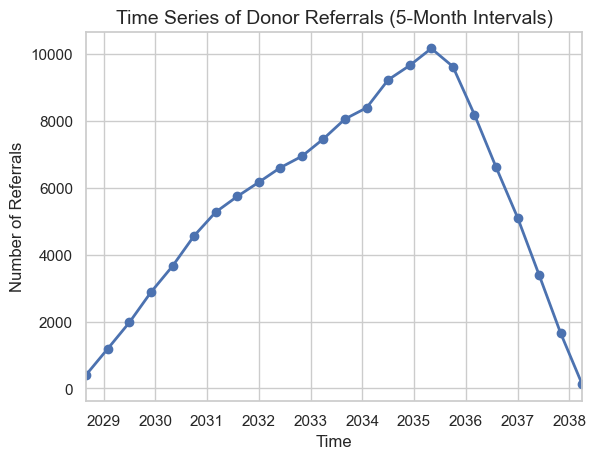

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the Excel file
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
df_RD = pd.read_excel(xls, "ReferralDetails")
# Grouping the data by 5-month intervals and counting the number of referrals in each interval
df_RD.set_index('time_referred', inplace=True)
# 5-month frequency starting from the beginning of the month
referral_counts = df_RD.resample('5MS').size()  
referral_counts.plot(kind='line', marker='o', color='b', linestyle='-', linewidth=2, markersize=6)
# Adding title and labels
plt.title('Time Series of Donor Referrals (5-Month Intervals)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Number of Referrals', fontsize=12)
# Display the plot
plt.show()

# Q4. Who is the oldest patient who died of drug overdose?

In [117]:
import pandas as pd
# Load the Excel file
df_DD =pd.read_excel(xls,"DonorDetails")
drug_overdose_df = df_DD [df_DD ['causeofdeath'] == 'Drug Overdose'] 
# Finding the oldest patient
oldest_patient = drug_overdose_df.loc[drug_overdose_df['age'].idxmax()]
# Displaying the result
print(f"The oldest patient who died of drug overdose is:")
print(oldest_patient)

The oldest patient who died of drug overdose is:
PatientID                    OPO5_P960496
age                                  74.0
gender                                  F
race                                White
causeofdeath                Drug Overdose
mechanism_of_death                Unknown
brain_death                             0
time_asystole         2035-11-05 05:45:00
time_brain_death                      NaT
Name: 120537, dtype: object


# Q5.What is the average age of patients with renal failure?

In [118]:
import pandas as pd
# Load the Excel file
df_DD =pd.read_excel(xls,"DonorDetails")
renal_failure_df = df_DD [df_DD ['causeofdeath'] == 'Renal  Disease']  
# average age of patients with renal failure
average_age = renal_failure_df['age'].mean()
# Displaying the result
print(f"The average age of patients with renal failure is: {average_age:.2f} years.")

The average age of patients with renal failure is: 61.68 years.


# Q6. List all male donors over 75 who had organs recovered for research

In [119]:
import pandas as pd
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
#Reading the Outcomes sheet
df_Out =pd.read_excel(xls,"Outcomes")
# Listing all male donors over 75 years old
male_over_75 = df_DD[(df_DD['gender'] == 'M') & (df_DD['age'] > 75)]
# columns in Outcomes that indicate organ recovery for research
research_columns = ['outcome_heart', 'outcome_liver', 'outcome_kidney_left', 'outcome_kidney_right',
                    'outcome_lung_left', 'outcome_lung_right', 'outcome_intestine', 'outcome_pancreas']
# Filtering outcome columns which contain 'Recovered for Research'
recovered_for_research = df_Out [df_Out [research_columns].apply(lambda x: 'Recovered for Research' in x.values, axis=1)]
# Merging the Donor Details and Outcomes data on PatientID
merged_df = pd.merge(male_over_75, recovered_for_research, on='PatientID')
merged_df['age']=merged_df['age'].apply(lambda x:round (x))
# list of male donors over 75 with organs recovered for research
print(merged_df)

       PatientID  age gender      race              causeofdeath  \
0   OPO1_P463597   76      M  Hispanic  cerebrovascular accident   
1   OPO3_P862019   83      M     White                    Anoxia   
2   OPO4_P199498   77      M     White  cerebrovascular accident   
3   OPO4_P877754   77      M     White  cerebrovascular accident   
4    OPO4_P92279   76      M  Hispanic               Head Trauma   
5   OPO4_P628770   77      M     White  cerebrovascular accident   
6   OPO4_P908004   76      M     White  cerebrovascular accident   
7   OPO4_P435716   78      M  Hispanic                    Anoxia   
8   OPO4_P487002   79      M     White  cerebrovascular accident   
9   OPO5_P287897   79      M     Black               Head Trauma   
10  OPO5_P463195   78      M     White               Head Trauma   
11  OPO5_P223804   78      M     Black                    Stroke   

   mechanism_of_death  brain_death       time_asystole    time_brain_death  \
0              Stroke            1   

# Q7. Make Patient ID as index to the table.

In [120]:
import pandas as pd
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
index_df=df_DD.set_index('PatientID')
print(index_df)

               age gender      race              causeofdeath  \
PatientID                                                       
OPO1_P155959  54.0      M     White                   Unknown   
OPO1_P297347  78.0      M  Hispanic                   Unknown   
OPO1_P399316  57.0      M  Hispanic                    Anoxia   
OPO1_P246407  78.0      F     Black  cerebrovascular accident   
OPO1_P187209  70.0      F     White                   Unknown   
...            ...    ...       ...                       ...   
OPO6_P54946   54.0      F     Black                    Anoxia   
OPO6_P630991  63.0      M     Black  cerebrovascular accident   
OPO6_P8748    28.0      M     White                    Anoxia   
OPO6_P5461    85.0      F     White                    Anoxia   
OPO6_P942291  32.0      M     Black                     Other   

             mechanism_of_death  brain_death       time_asystole  \
PatientID                                                          
OPO1_P155959      

# Q8. "Create a dictionary with the Age and Cause of Death for any 5 random donors.Access any one cause of death using the donors age using the get() function"

In [121]:
import pandas as pd
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
age_causeOfDeath=df_DD[['age','causeofdeath']]
random_donors=age_causeOfDeath.sample(n=5, random_state=1)
donor_dict=random_donors.set_index('age')['causeofdeath'].to_dict()
print(f'Dictionary with the Age and Cause of Death for any 5 random donors:\n{donor_dict}')
print(f'\nAccessing one cause of death using the donors age using the get() function:\n{donor_dict.get(31)}')

Dictionary with the Age and Cause of Death for any 5 random donors:
{31.0: 'Anoxia', 69.0: 'cerebrovascular accident', 60.0: 'Exsanguination', 49.0: 'cerebrovascular accident', 59.0: 'Infectious Disease - Viral'}

Accessing one cause of death using the donors age using the get() function:
Anoxia


# Q9.Create a heatmap on the donor details table.

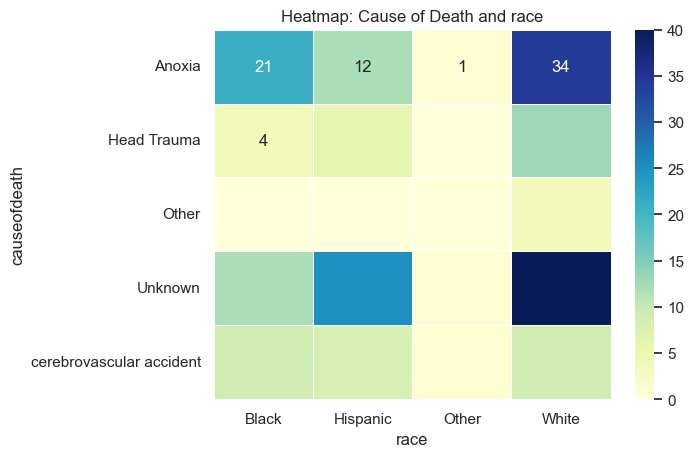

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
df_DD = pd.read_excel(xls, "DonorDetails")
# Selecting the first 200 rows of data for better Vizualization
df_DD_top200 = df_DD.head(200)
# Creating a pivot table for 'causeofdeath' and 'race'
pivot_table = df_DD_top200.pivot_table(index='causeofdeath', columns='race', aggfunc='size', fill_value=0)
# Plotting the heatmap
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt="d", cbar=True, linewidths=0.5)
plt.title('Heatmap: Cause of Death and race')
# Show the plot
plt.show()

# Q10."Create a bar chart showing the number of donors by procured year. Add hatching to the bars using the set_hatch() method, and exclude any outlier years."

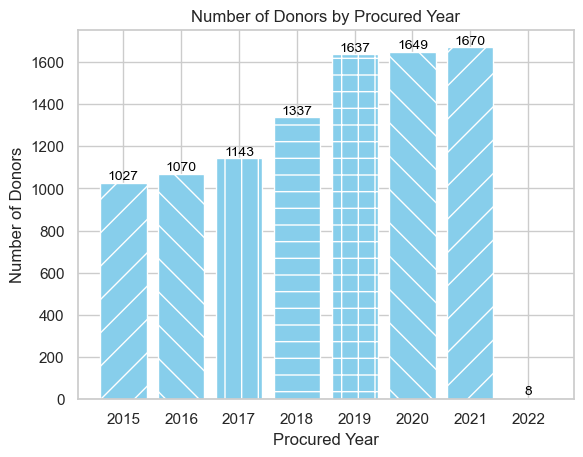

In [195]:
# Load the Excel file and DonorDetails sheet
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
df_DD = pd.read_excel(xls, "ReferralDetails")
# Removing outliers for 'Procured_Year'
mean_year = df_DD['Procured_Year'].mean()
std_year = df_DD['Procured_Year'].std()
# Excluding years more than 2 standard deviations away from the mean
df_filtered = df_DD[(df_DD['Procured_Year'] >= mean_year - 2 * std_year) & 
                    (df_DD['Procured_Year'] <= mean_year + 2 * std_year)]
# Grouping by 'Procured_Year' and counting the number of donors
donors_by_year = df_filtered.groupby('Procured_Year').size()
# Creating the bar chart
bars = plt.bar(donors_by_year.index, donors_by_year.values, color='skyblue')
# Adding hatch patterns
hatches = ['/', '\\', '|','-', '+','\\','/']
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)
    # Adding count values on the bars
for bar in bars:
    plt.gca().annotate(
        f'{int(bar.get_height())}',  
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  
        ha='center', va='bottom',  
        fontsize=10, color='black'  
    )

# Adding labels and title
plt.title('Number of Donors by Procured Year')
plt.xlabel('Procured Year')
plt.ylabel('Number of Donors')
# Showing the plot
plt.show()

# Q11. Plot a Donut chart to show donor distribution by Gender.

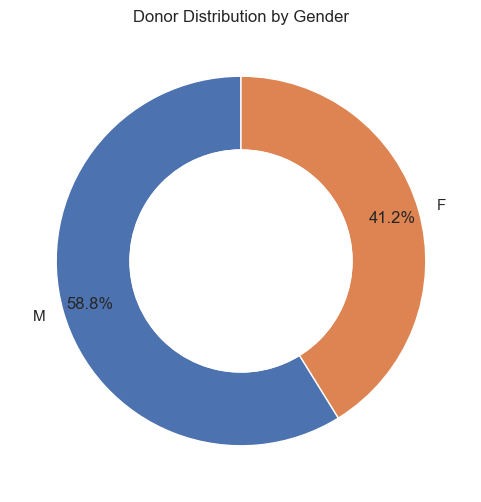

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
# Counting the number of donors by gender
gender_counts = df_DD['gender'].value_counts()
# Plotting the donut chart
plt.figure(figsize=(6,6))
# Pie Chart
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.4}, pctdistance=0.85)
# Drawing a circle 
centre_circle = plt.Circle((0,0), 0.6, color='white', fc='white', linewidth=1.25)
plt.gca().add_artist(centre_circle)
# Displaying the chart
plt.title('Donor Distribution by Gender')
plt.show()

# Q12.Using loc, retrieve the race and time of aysytole of donors between indices 1001 and 2001.

In [125]:
res = df_DD.loc[1001:2001, ['race', 'time_asystole']]
print(res)

          race       time_asystole
1001     White 2034-03-28 16:47:00
1002  Hispanic                 NaT
1003     White 2034-01-19 12:00:00
1004  Hispanic 2032-01-19 18:49:00
1005  Hispanic 2036-02-05 18:31:00
...        ...                 ...
1997  Hispanic 2037-05-19 23:10:00
1998  Hispanic                 NaT
1999     White 2034-11-20 21:21:00
2000  Hispanic 2034-02-04 15:00:00
2001     White 2035-06-15 05:58:00

[1001 rows x 2 columns]


# Q13. "np.arange(1,31).reshape(6,5) 1. Find array slicing to get the elements 1,2,8,30. 2. When the value is less than 9, print as 0,else print 99"


In [126]:
import numpy as np
arr=np.arange(1,31).reshape(6,5)
print(arr)
elements=[arr[0,0],arr[0,1],arr[1,2],arr[5,4]]
print(f'\nSelected elements are :{elements}')
modified_arr=np.where(arr <9, 0,99)
print("\nModified array: 0 if <9 else 99: ")
print(modified_arr)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]
 [26 27 28 29 30]]

Selected elements are :[1, 2, 8, 30]

Modified array: 0 if <9 else 99: 
[[ 0  0  0  0  0]
 [ 0  0  0 99 99]
 [99 99 99 99 99]
 [99 99 99 99 99]
 [99 99 99 99 99]
 [99 99 99 99 99]]


# Q14.	"Create subplots for the following data x = np.arange(0, 10, 0.1) y = np.sin(np.pi * x) + x using an object-oriented approach, and arrange the subplots in a 2x2 grid layout"


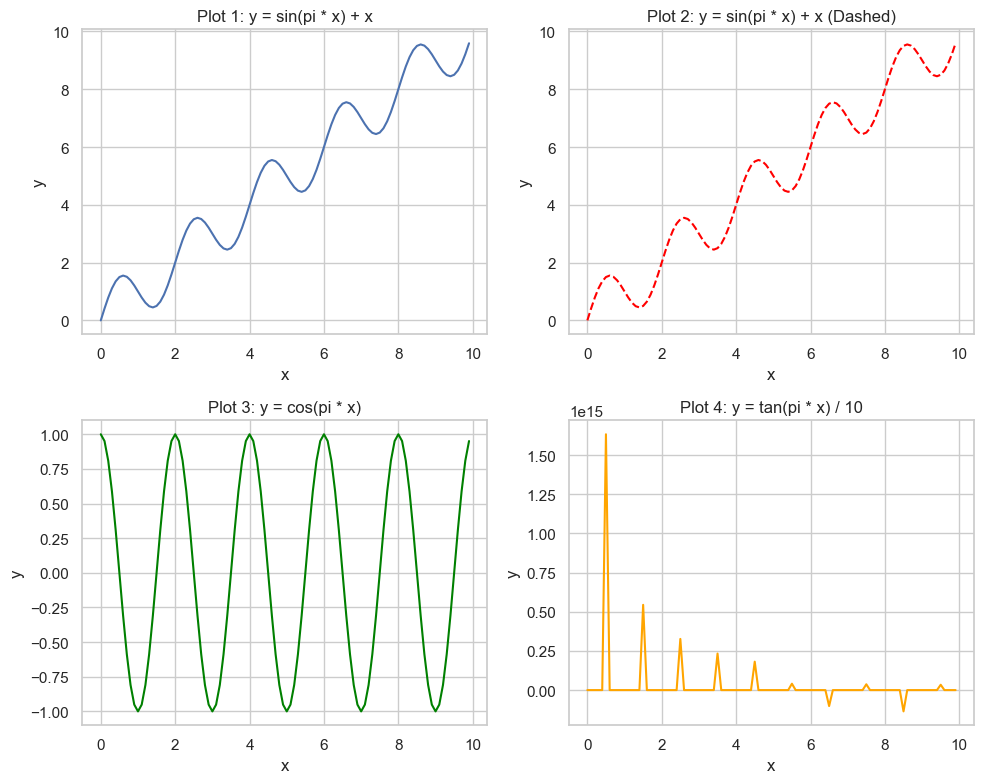

In [127]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(0, 10, 0.1)
y = np.sin(np.pi * x) + x
# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# first subplot at top-left
axes[0, 0].plot(x, y)
axes[0, 0].set_title('Plot 1: y = sin(pi * x) + x')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
# second subplot at top-right
axes[0, 1].plot(x, y, color='red', linestyle='--')
axes[0, 1].set_title('Plot 2: y = sin(pi * x) + x (Dashed)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')
# third subplot at bottom-left
axes[1, 0].plot(x, np.cos(np.pi * x), color='green')
axes[1, 0].set_title('Plot 3: y = cos(pi * x)')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
# fourth subplot at bottom-right
axes[1, 1].plot(x, np.tan(np.pi * x) / 10, color='orange')
axes[1, 1].set_title('Plot 4: y = tan(pi * x) / 10')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('y')
# Adjusting layout 
plt.tight_layout()
plt.show()

# Q15.Create a box plot on any values in the dataset. Ensure that it is analytically correct.

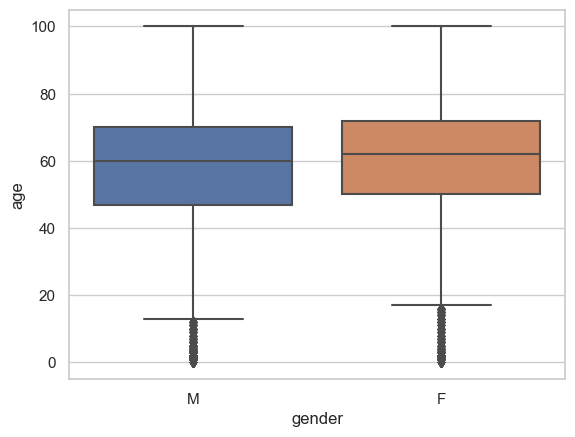

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
xls=pd.ExcelFile("OrganDonor_Consolidated.xlsx")
df_DD=pd.read_excel(xls, "DonorDetails")
sns.boxplot(x='gender',y='age',data=df_DD)
plt.show()

# Q16.How many donors were registered in each Organ Procurement Organization?

In [129]:
import pandas as pd
xls=pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the OPO_HospDetails sheet
df_OPO =pd.read_excel(xls,"OPO_HospDetails")
#using count method, to find the number of donors registered in each OPO
donors_registered = df_OPO.groupby(["OPO"])["PatientID"].count()
#convert the result into dataframe and name it
donors_registered.name = "Number_of_Donors"
df_donors_per_OPO = donors_registered.to_frame()
# Display the result
df_donors_per_OPO = df_donors_per_OPO.sort_values(by="OPO")
print(df_donors_per_OPO)

      Number_of_Donors
OPO                   
OPO1             32148
OPO2             16145
OPO3             12514
OPO4             33641
OPO5             15738
OPO6             22915


# Q17. Calculate the average time between referral and procurement for each mechanism of death

In [130]:
import pandas as pd
# Load the Excel file
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
df_DD = pd.read_excel(xls, "DonorDetails")
df_RD = pd.read_excel(xls, "ReferralDetails")
#Merging the two DataFrames on the common 'PatientID'
merged_df = pd.merge(df_RD, df_DD, on='PatientID', how='inner')
# Calculating the time difference between 'time_referred' and 'time_procured' (in days)
merged_df['Time_to_Procurement'] = (merged_df['time_procured'] - merged_df['time_referred']).dt.days
# Grouping by 'mechanism_of_death' and calculating the average time to procurement (in days)
avg_time_by_mechanism = merged_df.groupby('mechanism_of_death')['Time_to_Procurement'].mean().reset_index()
print(avg_time_by_mechanism.round(2))

           mechanism_of_death  Time_to_Procurement
0                Asphyxiation                 4.14
1                Blunt Injury                 3.96
2              Cardiovascular                 3.70
3   Death from Natural Causes                 2.19
4                    Drowning                 4.35
5           Drug Intoxication                 3.84
6                  Electrical                 4.25
7              Gun Shot Wound                 3.47
8               Gunshot Wound                 2.56
9              Natural Causes                 3.95
10          None of the Above                 3.74
11          None of the above                 1.80
12                      Other                 2.00
13                    Seizure                 3.70
14                       Stab                 3.47
15                     Stroke                 3.09
16        Sudden Infant Death                 3.40
17                    Unknown             -4042.40


# Q18. What % of all referrals are procured?

In [131]:
import pandas as pd
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
#Reading the Donor Details sheet
df_DD =pd.read_excel(xls,"DonorDetails")
#Reading the Referra Details sheet
df_RD =pd.read_excel(xls,"ReferralDetails")
#Merging the two DataFrames on the common 'PatientID'
merged_df=pd.merge(df_RD, df_DD, on='PatientID')
# Counting the total number of referrals
all_referrals = len(df_RD)
# Counting the number of procured referrals
procured_referrals = len(merged_df[merged_df['Procured_Year'].notna()])
# Calculating the percentage of procured referrals
procured_percentage = (procured_referrals / all_referrals) * 100
print(f"All Referrals: {all_referrals}")
print(f"Procured Referrals: {procured_referrals}")
print(f"Percentage of Referrals Procured: {procured_percentage:.2f}%")

All Referrals: 133101
Procured Referrals: 9543
Percentage of Referrals Procured: 7.17%


# Q19. Write a function to calculate the year of birth for each patient using year of referral as a base.

In [132]:
import pandas as pd
# Load the Excel file
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
df_DD = pd.read_excel(xls, "DonorDetails")
df_RD = pd.read_excel(xls, "ReferralDetails")
def calculate_year_of_birth():
    merged_df = pd.merge(df_RD, df_DD, on='PatientID', how='inner')
    # Year of Birth= Year of Referral - Age at Referral
    merged_df['Year of Birth'] = merged_df['Referral_Year'] - merged_df['age']
    merged_df['Year of Birth'] = merged_df['Year of Birth'].fillna(0).round().astype(int)
    # Return the updated DataFrame with the Year of Birth
    return merged_df
# Calling the function to calculate the year of birth
df_with_yob = calculate_year_of_birth()
print(df_with_yob[['PatientID','Year of Birth']].head(10))

      PatientID  Year of Birth
0  OPO1_P320866           1956
1  OPO1_P549364           2007
2  OPO1_P536997           1960
3  OPO1_P463285           1971
4  OPO1_P284978           1938
5  OPO1_P127497           1994
6  OPO1_P850186           1939
7  OPO1_P852477           1986
8  OPO1_P990202           1971
9  OPO1_P768244           1992


# Q20. How many patients have died of sepsis following drowning incidents?

In [133]:
import pandas as pd
# Load the Excel file
xls = pd.ExcelFile("OrganDonor_Consolidated.xlsx")
df_DD = pd.read_excel(xls, "DonorDetails")
sepsis_after_drowning = df_DD[(df_DD['causeofdeath'] == 'Sepsis') & (df_DD['mechanism_of_death'] == 'Drowning')]
# count of matching patients
patient_count = sepsis_after_drowning.shape[0]
# Printing the result
print(f"Number of patients who died of Sepsis following Drowning incidents: {patient_count}")

Number of patients who died of Sepsis following Drowning incidents: 1


## Q21. What percentage of all procurements are actually transplanted?

In [134]:
# Check if all specified columns exist in the DataFrame
required_columns = [
    'outcome_heart', 'outcome_liver', 'outcome_kidney_left', 'outcome_kidney_right','outcome_lung_left', 'outcome_lung_right', 'outcome_intestine', 'outcome_pancreas']

for col in required_columns:
# Count total procurements across specified columns
    total_procurements = df_Out[required_columns].notna().sum().sum()
# Count transplanted outcomes across specified columns
    transplanted_count = sum( (df_Out[col] == 'Transplanted').sum() for col in required_columns )

# Calculate percentage
percentage_transplanted = (transplanted_count / total_procurements) * 100
print(f"Percentage of procurements transplanted: {percentage_transplanted:.2f}%")

Percentage of procurements transplanted: 77.12%


## Q.22 What is the ratio of referrals to procurements per year?

In [135]:
# Count of referral year
referral_year = df_RD['Referral_Year'].value_counts().astype(int)
# Count of procured year
procured_year = df_RD['Procured_Year'].value_counts().astype(int)

#ratio of referral and procured year
ratio = referral_year/procured_year

#print ratio
print(ratio)

1987.0          NaN
2015.0    12.570594
2016.0    12.000000
2017.0    12.758530
2018.0    14.341810
2019.0    12.783751
2020.0    15.158278
2021.0    16.568862
2022.0          NaN
Name: count, dtype: float64


## Q.23 How many referrals occurred in 2018?

In [136]:
# Filter the values only for Referral_Year is 2018
referrals_in_2018 = df_RD[df_RD['Referral_Year'] == 2018]

#Count the number of rows with year 2018
total_referrals_in_2018 = referrals_in_2018.shape[0]

print("Total referrals in 2018:",total_referrals_in_2018 )

Total referrals in 2018: 19175


## Q.24 Which hospital had the lowest rate of lung transplants? Procured but not transplanted

In [137]:
df_lungs = df_Out[['outcome_lung_left', 'outcome_lung_right','PatientID' ]].dropna()

#filter the values except transplanted
df_filter = df_lungs.loc[(df_lungs['outcome_lung_left'] != 'Transplanted') & (df_lungs['outcome_lung_right'] != 'Transplanted')]

#merging columns
df_merge = pd.merge(df_lungs, df_OPO, on='PatientID', how='inner')

# group and count HospitalId. idxmin() for finding the min value
hospital_id = df_merge.groupby('HospitalID').size().idxmin()

print(f"{hospital_id} had the lowest rate of lung transplants")


OPO1_H10961 had the lowest rate of lung transplants


## Q.25 In donors where brain death occurred, what was the time difference between brain death and asystole?

In [138]:
df_death_causes = df_DD[['time_brain_death', 'time_asystole', 'brain_death']].dropna()

df_death_causes
# Filter the donors who had brain death
df_death_causes_brain = df_death_causes[df_death_causes['brain_death'] == 1]
df_death_causes_brain

#finding the difference 
difference = (df_death_causes_brain['time_asystole'] - df_death_causes_brain['time_brain_death'])
difference

114      0 days 20:08:00
135      0 days 20:35:00
154      0 days 07:37:00
159      0 days 09:15:00
239      2 days 21:09:00
               ...      
129973   2 days 04:53:00
130627   0 days 00:00:00
131195   0 days 01:59:00
131656   0 days 15:38:00
132866   0 days 00:00:00
Length: 3519, dtype: timedelta64[ns]

## Q.26 Which OPO recorded the highest calculated deaths in the year 2015?

In [139]:
#Filter the DataFrame for the year 2015
df_2015 = df_Year[df_Year['Year'] == 2015]

#group by OPO counts and deat#h
opo_counts = df_2015.groupby('OPO').size()

#finding the heighest values
highest_opo = opo_counts.idxmax() 

print(f" {highest_opo} recorded the highest deaths in 2015 ")


 OPO1 recorded the highest deaths in 2015 


## Q.27 Create a pivot table shows organ-based outcome type as rows and outcome statuses as columns

In [140]:
df_out = df_Out[['outcome_heart', 'outcome_kidney_left', 'outcome_kidney_right',
                 'outcome_lung_left', 'outcome_lung_right', 'outcome_intestine', 'outcome_pancreas']]

# melt() function is used to change the DataFrame format from wide to long.Melt the DataFrame to make outcome_types rows
df_melted = df_out.melt(var_name='outcome_type', value_name='outcome_status')

# Create a DF with outcome_type and outcome_status
pivot_table = df_melted.pivot_table(
     index='outcome_type', 
    columns='outcome_status', 
    aggfunc='size',  # Counts the number of occurrences for each outcome_status 
)

# Display the pivot table
print(pivot_table)

outcome_status        Recovered for Research  \
outcome_type                                   
outcome_heart                            682   
outcome_intestine                        279   
outcome_kidney_left                      466   
outcome_kidney_right                     459   
outcome_lung_left                       1182   
outcome_lung_right                      1246   
outcome_pancreas                         627   

outcome_status        Recovered for Transplant but not Transplanted  \
outcome_type                                                          
outcome_heart                                                    21   
outcome_intestine                                                 4   
outcome_kidney_left                                            1252   
outcome_kidney_right                                           1300   
outcome_lung_left                                                79   
outcome_lung_right                                               74   

## Q.28 What is the average drop in procurement rate between each successive 4-hour period and visualize the trend.

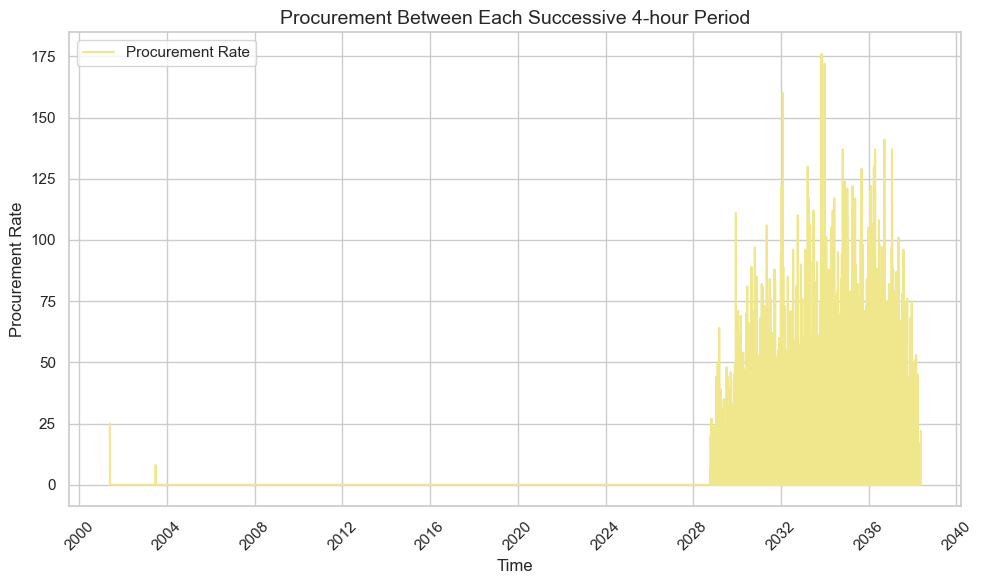

In [141]:
#df_procured = df_RD[['time_procured']]

# Convert 'time_procured' to datetime 
df_RD['time_procured']= pd.to_datetime(df_RD['time_procured'].fillna(method='ffill'))

# Set 'time_procured' as the index
df_procured = df_RD.set_index('time_procured')

# Resample the data to get procurement counts every 4 hours
df_procured_4hr = df_procured.resample('4H').size()

#calculates the difference between successive periods. diff() calculate difference between time periods
drop_in_procurement = df_procured_4hr.diff().dropna()   

# Calculate the average drop 
avg_drop = drop_in_procurement.mean()

#Plot the trend of procurement counts
plt.figure(figsize=(10, 6))
plt.plot(df_procured_4hr.index, df_procured_4hr, label='Procurement Rate', color='khaki')
plt.title('Procurement Between Each Successive 4-hour Period', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Procurement Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

#Show the plot
plt.tight_layout()
plt.show()

# Print the average drop in procurement rate
#print(f"Average drop in procurement rate between successive 4-hour periods: {avg_drop:.2f}")


## Q.29 How many deaths were registered with OPO 1? List them by year.

In [142]:
# Filter rows where OPO is equal to OPO1
df_year = df_Year[df_Year['OPO'] == 'OPO1']

#group the year with deaths count
deaths_count_by_year = df_year.groupby('Year')['mean calc deaths'].sum().reset_index()

# print the result
print(deaths_count_by_year)


   Year  mean calc deaths
0  2015           2852.69
1  2016           2954.13
2  2017           3112.34
3  2018           3019.04
4  2019           3148.80
5  2020           3236.50


## Q.30 What percentage of all procurements are used for research?

In [143]:
#all outcomes
df_research = df_Out[['outcome_heart', 'outcome_kidney_left', 'outcome_kidney_right',
                 'outcome_lung_left', 'outcome_lung_right', 'outcome_intestine', 'outcome_pancreas']].dropna()
#count of outcomes
total_research = df_research.dropna().count().sum()
#count only transplanted
Used_for_research = (df_research.dropna() =='Recovered for Research').sum().sum()
#percentage
percentage = (Used_for_research/total_research)*100
print(f"Percentage of  all procurements are used for research is {percentage:.2f}%")

Percentage of  all procurements are used for research is 30.77%


## Q.31 How many donors with a successful transplant died of a seizure?

In [144]:
# Donors who died of a seizure
df_dd = df_DD[df_DD['causeofdeath'] == 'Seizure']

# dDonors with transplant value 1
df_rd = df_RD.loc[df_RD['transplanted'] == 1] 

# Merge donor details & referraldetails dataframes on 'PatientID'
df_merge = pd.merge(df_dd, df_rd, on='PatientID', how='inner')

# Count the donors with len()
donor_count = len(df_merge)

print(f"Number of donors with a successful transplant who died of a seizure: {donor_count}")


Number of donors with a successful transplant who died of a seizure: 3


## Q.32 Create a sunburst chart of age, race and any one outcome

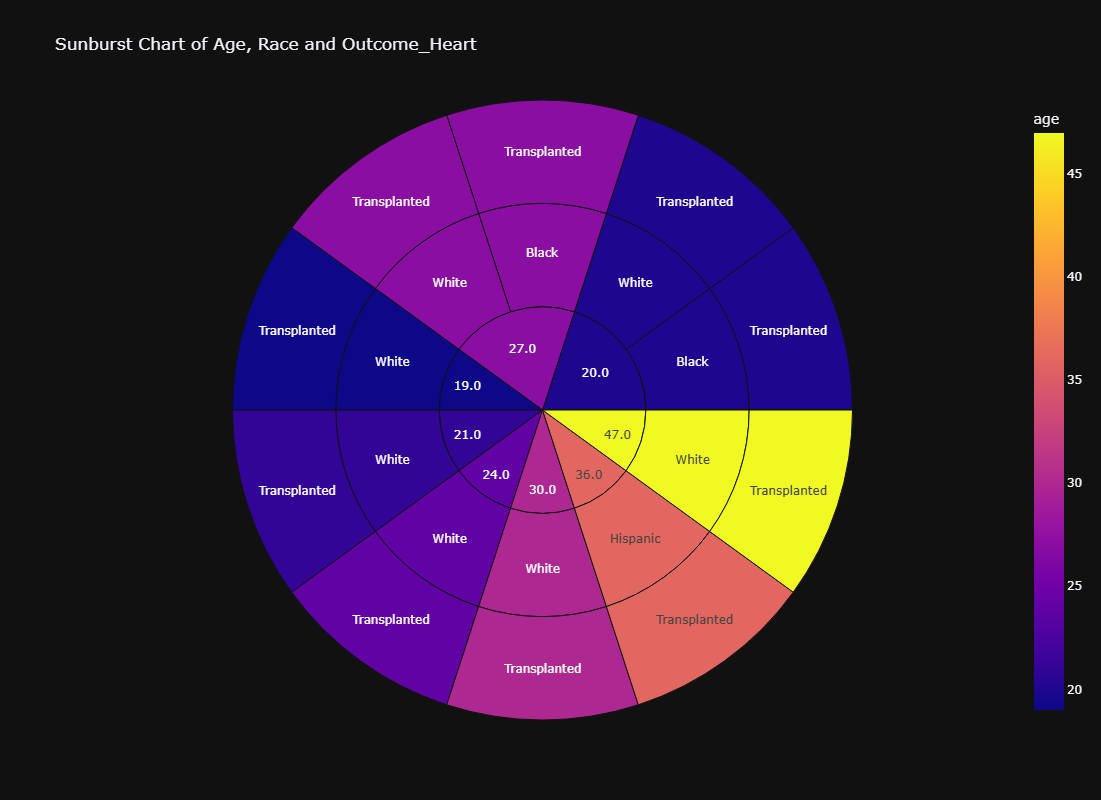

In [145]:
#df_dd = df_DD[['age','race','PatientID']]
#df_out = df_Out[['outcome_heart', 'PatientID']]

#merge columns
df_combined = pd.merge(df_DD, df_Out, on='PatientID', how='inner').dropna()

#filter to outcome_heart as Transplanted
df_combined_transplanted = df_combined[df_combined['outcome_heart'] == 'Transplanted']

fig = px.sunburst(
   df_combined_transplanted,
    path=['age', 'race', 'outcome_heart'], 
    height =800,
    maxdepth=-3,
    title="Sunburst Chart of Age, Race and Outcome_Heart",
    color='age',
    template="plotly_dark",color_discrete_sequence= px.colors.qualitative.Prism
)

# Show the chart
fig.show()


## Q.33 Which year had the maximum referrals.

In [146]:
# group and count referral years
referrals_by_year = df_RD.groupby('Referral_Year').size()

# Finding the year with the maximum referrals
max_referrals_year = referrals_by_year.idxmax()

print(f"The year {max_referrals_year} recorded the maximum referrals.")

The year 2021 recorded the maximum referrals.


## Q.34 How many organs are recovered for transplant but not transplanted?

In [147]:

df_columns = df_Out[['outcome_heart', 'outcome_liver', 'outcome_kidney_left', 'outcome_kidney_right',
           'outcome_lung_left', 'outcome_lung_right', 'outcome_intestine', 'outcome_pancreas']].dropna()

# Count 'recovered for transplant but not transplanted' value across the columns. '.sum().sum()' - Total count across all rows and columns
count = df_columns.apply(lambda col: col.str.contains('Recovered for Transplant but not Transplanted', case=True).sum()).sum()

print(f"{count} organs are recovered for transplant but not transplanted")


16 organs are recovered for transplant but not transplanted


## Q.35 What are the 3 most frequent causes of death?

In [148]:
df_dd = df_DD[['causeofdeath']]

# 3 most frequent causes of death
top_3_causes = df_dd['causeofdeath'].value_counts().head(3)

print(top_3_causes)

causeofdeath
Anoxia                      35903
Unknown                     26780
cerebrovascular accident    16797
Name: count, dtype: int64


## Q.36 How many transplants were registered under each OPO?

In [149]:
#filter the succesdul transplanted values
rd = df_RD[df_RD['transplanted'] == 1]

#split the platientID values for each OPO
rd_opo = rd['PatientID'].str.split("_").str[0]

#count the opo values
transplants_per_opo = rd_opo.value_counts()

print(transplants_per_opo)

PatientID
OPO1    2558
OPO4    2265
OPO5    1510
OPO6    1201
OPO2     846
OPO3     592
Name: count, dtype: int64


## Q.37 Plot a stacked bar chart to show different procurement outcomes for organs - heart, liver, and pancreas. Label the bars with the actual numbers for each outcome.

Text(0.5, 1.0, 'Procurement Outcomes For Organs')

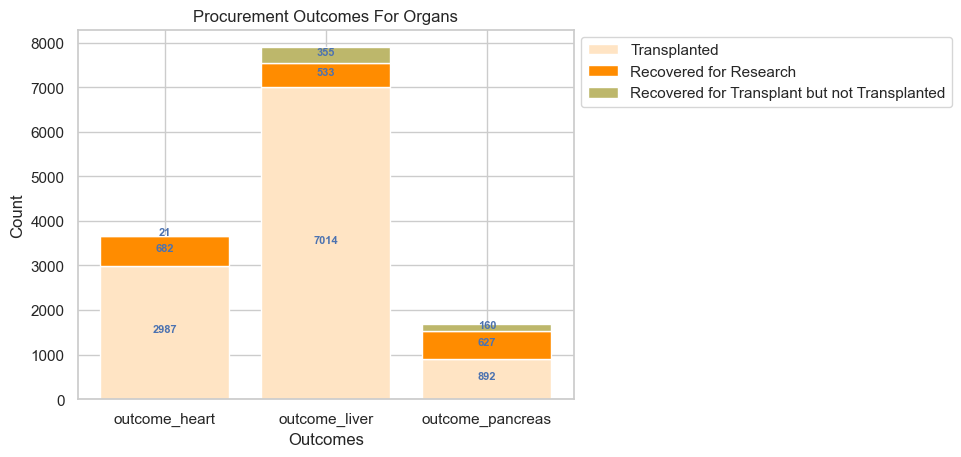

In [150]:
df_columns = df_Out[['outcome_heart', 'outcome_liver','outcome_pancreas']]

#cout the values in each outcome. fillna(0)- replace missing values with 0. astype- convert counts to integer values
count_by_data = df_columns.apply(pd.Series.value_counts).fillna(0).astype(int)

#Transposes the DF, switching rows and columns{each row represents an outcomes, & each column represents a specific organ}
df_transpose = count_by_data.transpose()

#x-axis of bar chart
x_axis = ['outcome_heart', 'outcome_liver', 'outcome_pancreas']

fig, ax = plt.subplots() 
ax.bar(x_axis, df_transpose['Transplanted'], color='bisque', label="Transplanted")
ax.bar(x_axis, df_transpose['Recovered for Research'], bottom= df_transpose['Transplanted'], color='darkorange', label= "Recovered for Research")
ax.bar(x_axis, df_transpose['Recovered for Transplant but not Transplanted'], bottom= df_transpose['Recovered for Research']+df_transpose['Transplanted'],color='darkkhaki', label="Recovered for Transplant but not Transplanted")

#labelling on the bars
for bar in ax.patches:
  ax.text(bar.get_x() + bar.get_width() / 2,
          bar.get_height() / 2 + bar.get_y(),
          round(bar.get_height()), ha = 'center',
          color = 'b', weight = 'bold', size = 8)

#labelling axis
ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) #positioning legends 
ax.set_ylabel('Count')
ax.set_xlabel('Outcomes')
ax.set_title('Procurement Outcomes For Organs')


## Q.38 What percentage of all transplants are lung transplants?

In [151]:
df_columns = df_Out[['outcome_heart', 'outcome_liver', 'outcome_kidney_left', 'outcome_kidney_right',
           'outcome_lung_left', 'outcome_lung_right', 'outcome_intestine', 'outcome_pancreas']].dropna()

# filter only for transplanted columns and get total count
total_transplants = (df_columns =='Transplanted').sum()

# Count for lung transplants 
lung_transplants = total_transplants['outcome_lung_left'] + total_transplants['outcome_lung_right']

## Calculate percentage
transplants_percentage = (lung_transplants/ (total_transplants.sum())) * 100

##print(f"The percentage of lung transplants is {round(transplants_percentage,2)}%")
print(f"The percentage of lung transplants is {transplants_percentage:.2f}%")


The percentage of lung transplants is 20.39%


## Q.39 Which year had the maximum number of procurements?

In [152]:
# group,count, find maximum procurements by year
max_procured_year = int(df_RD.groupby('Procured_Year').size().idxmax())

#print 
print(f"The year {max_procured_year} had the maximum number of procurements.")

The year 2021 had the maximum number of procurements.


## Q.40 Create a dataframe with date and time as columns, where the values are the referral time

In [153]:
# Extract date and time into separate columns with "df['Time'] = df['Datetime'].dt.time"
new_df = pd.DataFrame()
new_df['Referral_Date'] = df_RD['time_referred'].dt.date
new_df['Referral_Time'] = df_RD['time_referred'].dt.time

print(new_df.head(10))

  Referral_Date    Referral_Time
0    2033-06-21         06:49:25
1    2036-11-21  08:41:13.397000
2    2030-08-23  23:28:54.687000
3    2034-05-12  17:34:52.277000
4    2033-02-22  04:45:27.867000
5    2034-08-28  10:21:44.060000
6    2029-10-12  21:23:25.890000
7    2037-04-27  07:22:20.810000
8    2036-07-21  02:34:35.510000
9    2035-10-12  03:01:57.493000


# Question 41. Create a pair plot of the outcomes, using different outcome statuses as the hue.

                                          status  heart  liver  kidney_left  \
0                                   Transplanted   2987   7014         7084   
1                         Recovered for Research    682    533          466   
2  Recovered for Transplant but not Transplanted     21    355         1252   

   kidney_right  lung_left  lung_right  intestine  pancreas  
0          7052       2146        2127         85       892  
1           459       1182        1246        279       627  
2          1300         79          74          4       160  


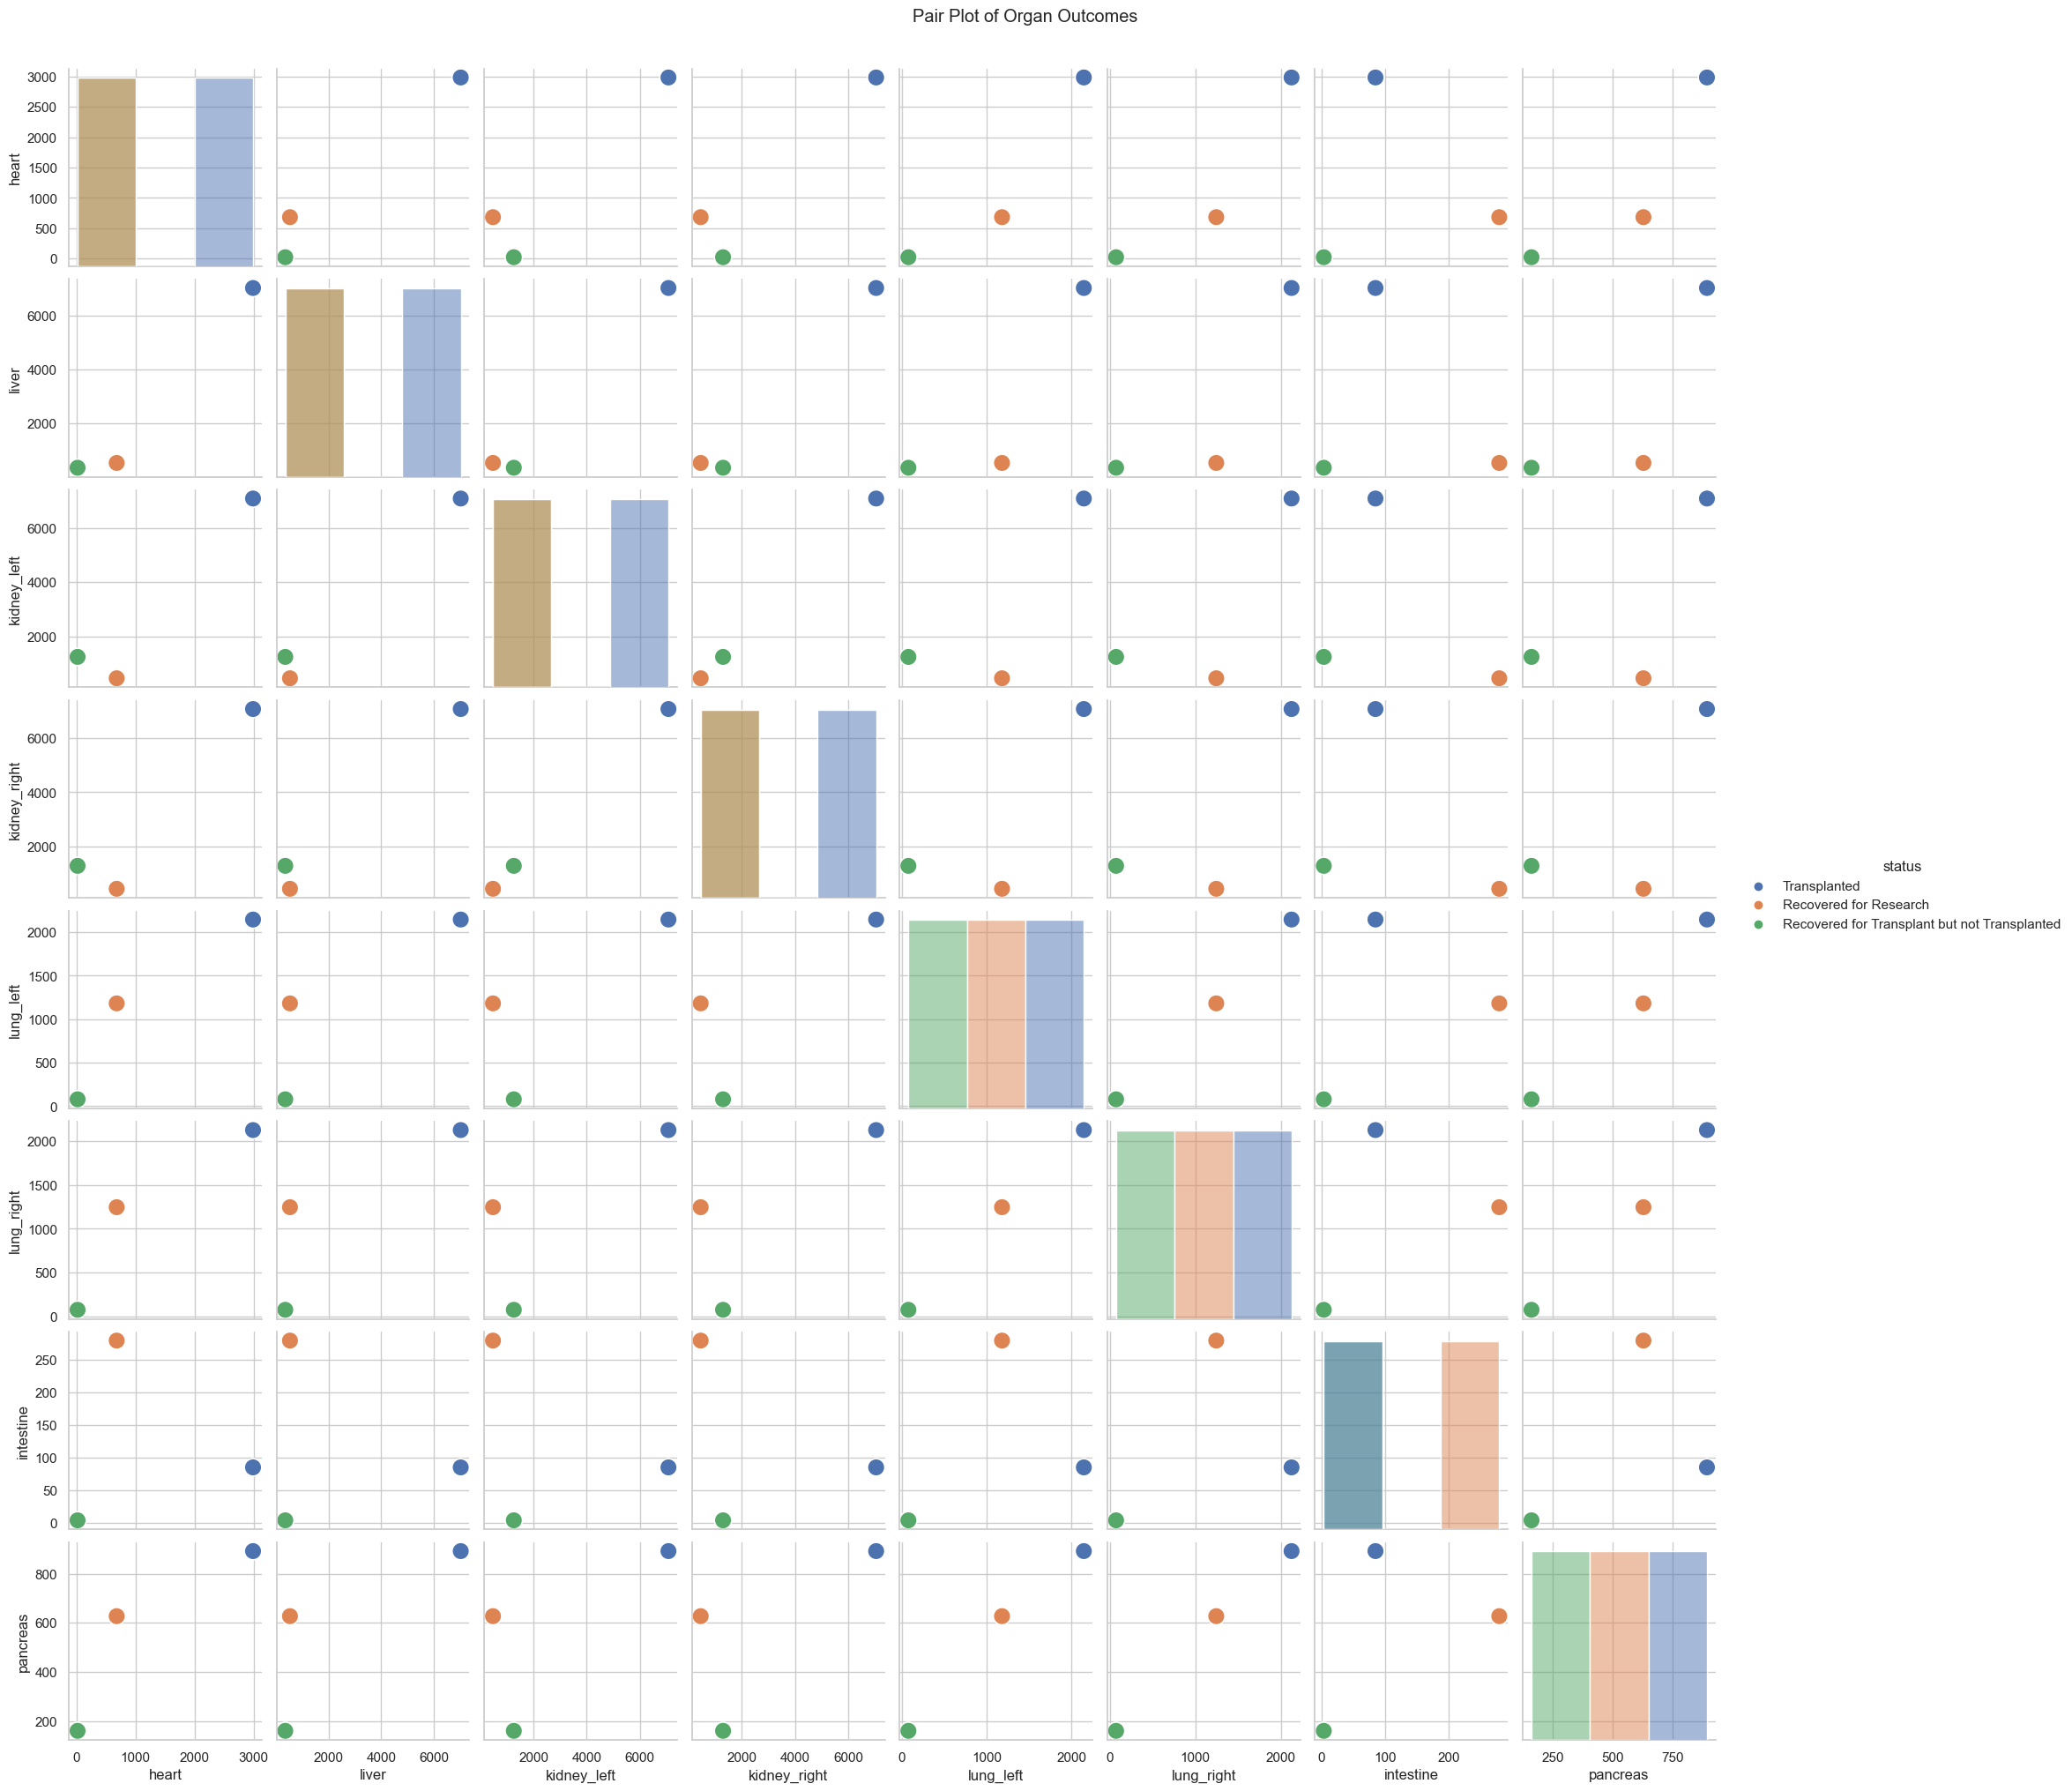

In [154]:
# loading the dataset into another for working
df_pairplot_try = df_Out.copy()
#creating the empty dataframe
df_try = pd.DataFrame()
# getting counts for each outcome organs
df_try['heart'] = df_pairplot_try['outcome_heart'].value_counts()
df_try['liver'] = df_pairplot_try['outcome_liver'].value_counts()
df_try['kidney_left'] = df_pairplot_try['outcome_kidney_left'].value_counts()
df_try['kidney_right'] = df_pairplot_try['outcome_kidney_right'].value_counts()
df_try['lung_left'] = df_pairplot_try['outcome_lung_left'].value_counts()
df_try['lung_right'] = df_pairplot_try['outcome_lung_right'].value_counts()
df_try['intestine'] = df_pairplot_try['outcome_intestine'].value_counts()
df_try['pancreas'] = df_pairplot_try['outcome_pancreas'].value_counts()
# assigning the status as a separate column
df_try = df_try.rename_axis('status')
df_reset = df_try.reset_index()
print(df_reset)
sns.pairplot(df_reset, hue = 'status', diag_kind="hist",
    plot_kws={'s': 200}  
)
#Customize and show
plt.suptitle("Pair Plot of Organ Outcomes", y=1.02)
plt.show()
plt.show()

# Question 42. What is the ratio of referrals to transplants by year?

In [155]:
refer_per_year = df_RD.groupby(["Referral_Year"])["PatientID"].count().rename('referrals')
df_Donors_tramsplant = df_RD[(df_RD['transplanted'] == 1)]
transplants_per_year = df_Donors_tramsplant.groupby(["Referral_Year"])["PatientID"].count().rename('transplants')
yearly_counts = pd.concat([refer_per_year, transplants_per_year], axis=1).fillna(0)
yearly_counts['ratio'] = round((yearly_counts['referrals'] / yearly_counts['transplants']),2)
print(yearly_counts)

               referrals  transplants  ratio
Referral_Year                               
2015               12910          979  13.19
2016               12840         1017  12.63
2017               14583         1100  13.26
2018               19175         1273  15.06
2019               20927         1556  13.45
2020               24996         1528  16.36
2021               27670         1519  18.22


# Question 43. How many donors died from a drug overdose?

In [156]:
df_Donors_died = df_DD[(df_DD['brain_death'] == 1) & (df_DD['causeofdeath'] == 'Drug Overdose')]
print(" Number of donors died from drug overdose - ", len(df_Donors_died))

 Number of donors died from drug overdose -  38


# Question 44.Create a count plot to show distribution of patient-ages in any 2 mechanisms of death.

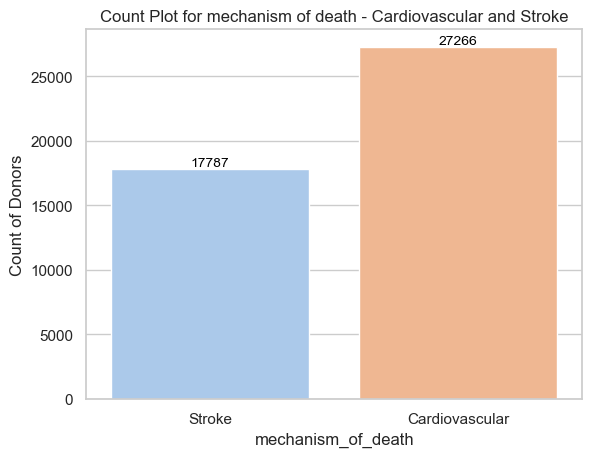

In [157]:
# filtering only 2 mechanisms of death for this problem
df_DD_mech_of_death = df_DD[(df_DD['mechanism_of_death'] == 'Cardiovascular') | (df_DD['mechanism_of_death'] == 'Stroke')]
# creating count plot using count plot method
chart2 = sns.countplot(x='mechanism_of_death', data=df_DD_mech_of_death, palette='pastel')

# Adding count values on the bars
for bar in chart2.patches:
    chart2.annotate(
        format(bar.get_height(), '.0f'),  
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  
        ha='center', va='bottom',  
        fontsize=10, color='black' 
    )

# Add labels and title
plt.title("Count Plot for mechanism of death - Cardiovascular and Stroke")
plt.xlabel("mechanism_of_death")
plt.ylabel("Count of Donors")
plt.show()

# Question 45. Create a Waffle chart to show what percentage of total deaths belong to each mechanism 

mechanism_of_death
Asphyxiation                  5
Blunt Injury                 17
Cardiovascular               19
Death from Natural Causes     1
Drowning                      1
Drug Intoxication             9
Electrical                    0
Gun Shot Wound                6
Gunshot Wound                 1
Natural Causes                4
None of the Above             3
None of the above             0
Other                         0
Seizure                       1
Stab                          0
Stroke                       31
Sudden Infant Death           0
Unknown                       1
dtype: int32


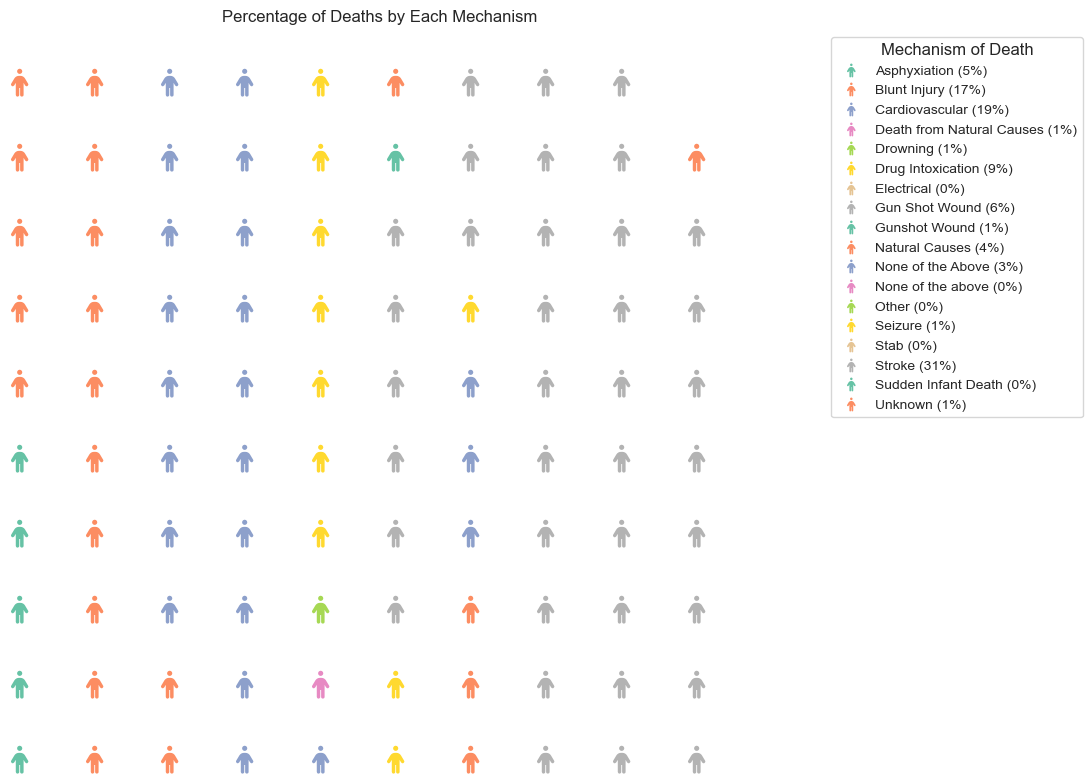

In [158]:
df_DD_ck = df_DD.copy()
deaths_per_mech = df_DD_ck[df_DD_ck['brain_death'] == 1].groupby('mechanism_of_death').size()
total_deaths = deaths_per_mech.sum()
death_percentages = (deaths_per_mech / total_deaths) * 100
death_percentages = death_percentages.round().astype(int)

print(death_percentages)
death_percentages = death_percentages.to_dict()

# Creating the waffle chart
fig = plt.figure(
    FigureClass=Waffle, 
    rows=10, 
    values=death_percentages, 
    title={'label': 'Percentage of Deaths by Each Mechanism', 'loc': 'center'},
    labels=[f"{key} ({value}%)" for key, value in death_percentages.items()],
    legend={
        'loc': 'upper left',            
        'bbox_to_anchor': (1.1, 1),    
        'fontsize': 10,
        'ncol': 1,                     
        'title': 'Mechanism of Death', 
        'title_fontsize': 12
    },
    figsize=(12, 8),
    icons='person',  
    icon_size=20,
    icon_legend=True
)

plt.show()

# Question 46.How many donors were registered under each hospital?

In [159]:
#using count method, to find the number of donors for each hospital
donors_per_hospital = df_OPO.groupby(["HospitalID"])["PatientID"].count()
#convert the result into dataframe and name it
donors_per_hospital.name = "Number_of_Donors"
df_donors_per_hospital = donors_per_hospital.to_frame()
# Display the result
df_donors_per_hospital = df_donors_per_hospital.sort_values(by="Number_of_Donors", ascending=False)
#printing only the top 20 records for better visual
print((df_donors_per_hospital).head(20))

             Number_of_Donors
HospitalID                   
OPO4_H16532              3682
OPO6_H22175              3629
OPO6_H6602               3578
OPO3_H4291               3123
OPO4_H30877              2335
OPO5_H10831              2268
OPO5_H8023               2163
OPO1_H27265              2064
OPO6_H14168              1858
OPO2_H12730              1849
OPO5_H6087               1796
OPO6_H16901              1778
OPO5_H1925               1737
OPO3_H11531              1708
OPO1_H23456              1684
OPO2_H2612               1667
OPO4_H11091              1565
OPO3_H9193               1497
OPO1_H18660              1487
OPO3_H6633               1434


# Question 47 . What is the predominant 'identified mechanism of death' among the youngest donors in the dataset.

In [160]:
##find youngest donor and place them in a separate dataframe
youngest_age = df_DD['age'].min() 
df_young_donors = df_DD[df_DD['age'] == youngest_age]
#print(type(df_young_donors))
# get the count of each mechanism of death among youngest donors
df_young_donors_mech = df_young_donors.groupby(["mechanism_of_death"])["PatientID"].count()
predominant_mechanism = df_young_donors_mech.idxmax()
predominant_count = df_young_donors_mech.max()
print(f"Predominant mechanism of death is : {predominant_mechanism}, {predominant_count} cases")

Predominant mechanism of death is : Unknown, 24 cases


# Question 48. Show a bar plot of the number of patients by race?

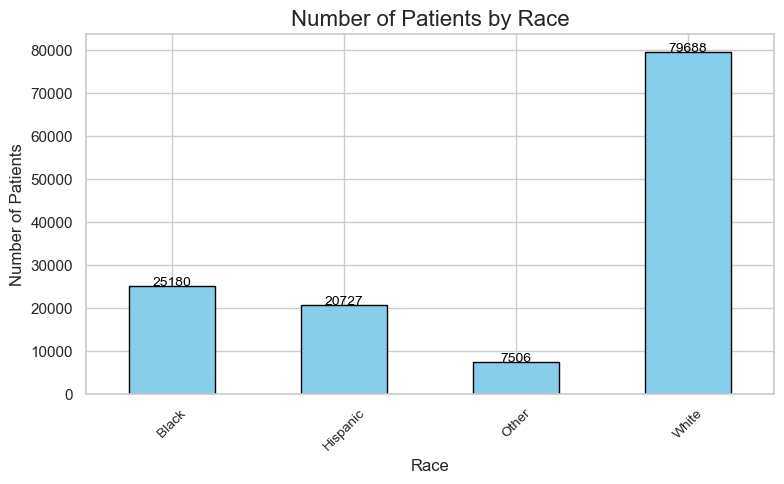

In [161]:
#using count methond, finding the number of patients in each race
patients_by_race = df_DD.groupby(["race"])["PatientID"].count()
# Plot the bar chart
plt.figure(figsize=(8, 5)) 
ax = patients_by_race.plot(kind='bar', color='skyblue', edgecolor='black')

# display the count on each bar
for i, count in enumerate(patients_by_race):
    plt.text(i, count + 0.1, str(count), ha='center', fontsize=10, color='black')

# Add titles and labels
plt.title('Number of Patients by Race', fontsize=16)
plt.xlabel('Race', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45, fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

# Question 49. Perform an EDA of hosp_details using YDATA Profiling.

In [162]:
profile = ProfileReport(df_OPO,
                        title="Hospital Details- Exploratory Data Analysis",
                        dataset={
                        "description": "Hospital and Patient Details for each OPO",
                        "copyright_holder": "Team2_Python_Sparks",
                    }) 
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Question 50.In how many cases were the relatives approached for consent vs how many were authorized?

In [163]:
df_relatives_approached = df_RD[(df_RD['Approached Relatives'] == 1) & (df_RD['Authorized By Family'] == 1)]
print(f"the relatives approached for consent vs how many were authorized : {len(df_relatives_approached)} cases")

the relatives approached for consent vs how many were authorized : 11962 cases


# Question 51.Which OPO recorded the lowest calculated deaths in any year?

In [164]:
lowes_calc_death = df_Year['mean calc deaths'].idxmin()
lowes_calc_death_value = df_Year.loc[lowes_calc_death, 'mean calc deaths']
lowes_calc_death_index = df_Year.loc[lowes_calc_death, 'OPO']
print(f"Lowest Calc death: {lowes_calc_death_value}, OPO with lowest calc death: {lowes_calc_death_index}")

Lowest Calc death: 656.265, OPO with lowest calc death: OPO3


# Question 52.Plot the Density Chart for Cause of Death- Seizure against any other variable of your choice

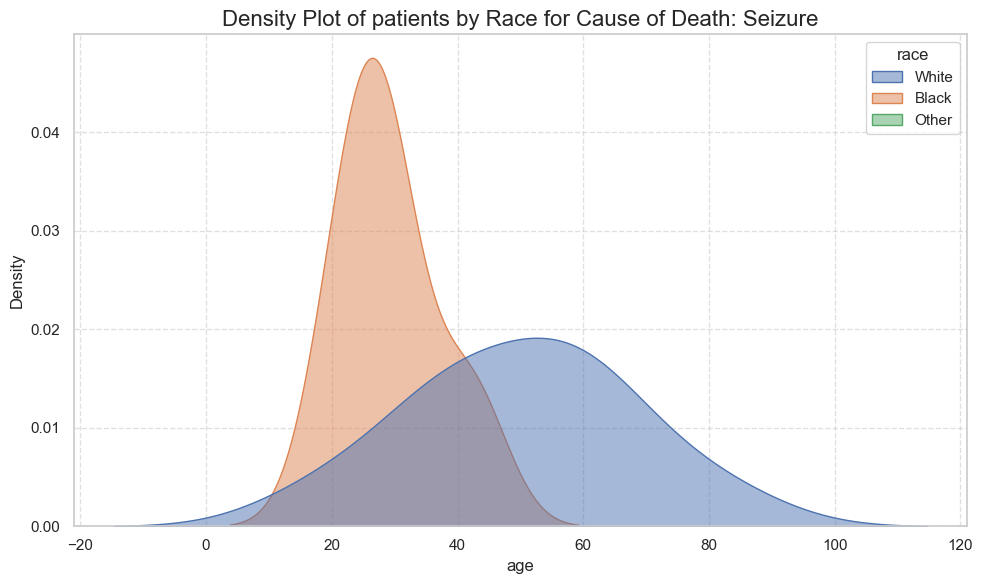

In [165]:
# Plot the density chart for cause of death of seizure by race
df_seizure = df_DD[(df_DD['causeofdeath'] == 'Seizure')]
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_seizure, x='age', hue='race', fill=True, alpha=0.5,  common_norm=False)
# Add titles and labels
plt.title('Density Plot of patients by Race for Cause of Death: Seizure', fontsize=16)
plt.xlabel('age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Question 53.Display a correlation matrix showing count of donors in age group vs cause of death

<function matplotlib.pyplot.show(close=None, block=None)>

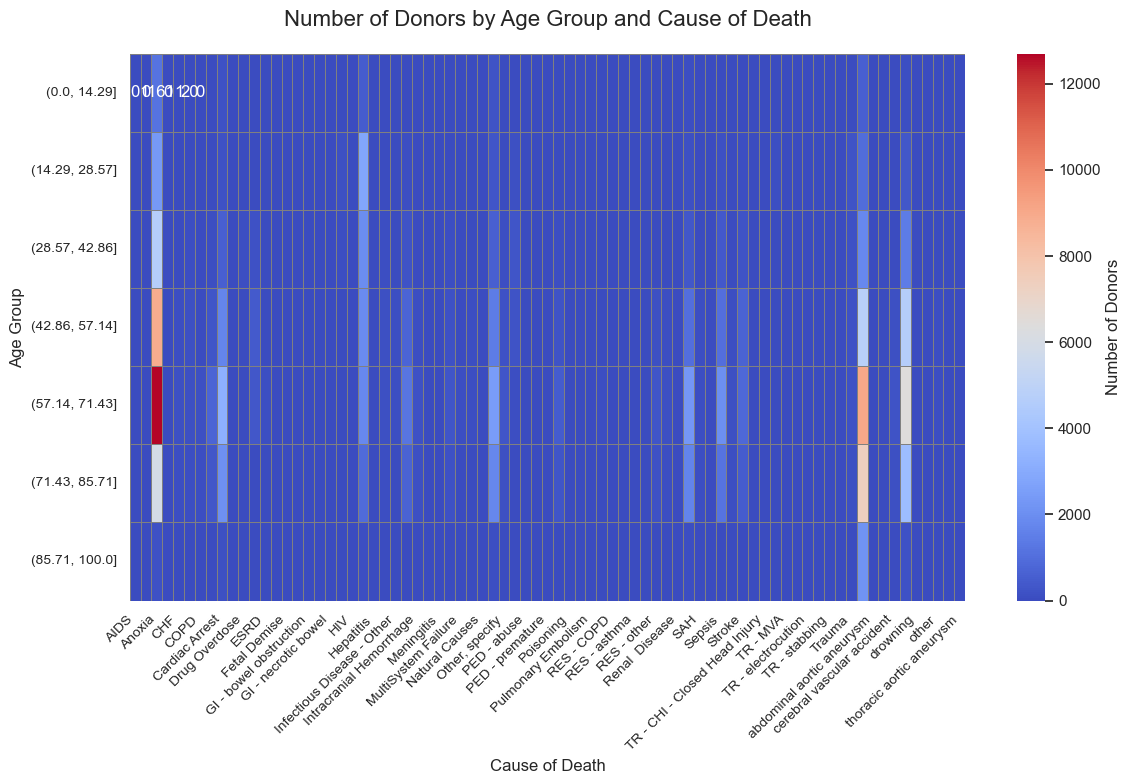

In [166]:
# Group by age group and cause of death
#created age_bins function as part of the question solved for age binning
# using binning method 'cut',  grouping the donors in each age bin
df_DD_age = df_DD.copy()
def age_bins(df_DD_age):
# Ensure to have only positive values inclueded
    df_DD_age = df_DD_age[df_DD_age['age'] >= 0]
# Define the number of bins
    num_bins = 7
    min_age = df_DD_age['age'].min()
    max_age = df_DD_age['age'].max()
# Generate bin edges dynamically based on min and max age
    bins = pd.interval_range(start=min_age, end=max_age, periods=num_bins)
# Round the edges to 2 decimal places and reconstruct intervals
    rounded_bins = [
    (round(interval.left, 2), round(interval.right, 2))
    for interval in bins
    ]
    final_bins = pd.IntervalIndex.from_tuples(rounded_bins)
# Assign age groups to bins using pd.cut binning method
    df_DD_age['age_group'] = pd.cut(df_DD_age['age'], bins=final_bins)
    return df_DD_age

def bin_counts_age(df_DD_age):    
# Count donors in each age group
    bin_counts = df_DD_age['age_group'].value_counts().sort_index()
    bin_counts.name = "Number_of_Donors_per_age_group"
    bin_counts = bin_counts.to_frame()
# Display the result
    #print(bin_counts)
    #df_DD_age_2 = df_DD_age.copy()
    return bin_counts
df_bin_age = age_bins(df_DD_age)
bin_age_count = bin_counts_age(df_bin_age)

# Group by age group and cause of death
grouped = df_bin_age.groupby(['age_group', 'causeofdeath'])['PatientID'].count().reset_index()

# Pivot table for matrix format
pivot_table = grouped.pivot(index='age_group', columns='causeofdeath', values='PatientID').fillna(0)

# Set up the figure size and style
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Plot a heatmap with enhanced styling
sns.heatmap(
    pivot_table,
    annot=True,              # Show numbers inside cells
    fmt=".0f",               # Format numbers as integers
    cmap="coolwarm",         # Change the color map
    cbar_kws={'label': 'Number of Donors'},  # Label for color bar
    linewidths=0.5,          # Add gridlines between cells
    linecolor='gray'         # Gridline color
)

# Add titles and axis labels
plt.title("Number of Donors by Age Group and Cause of Death", fontsize=16, pad=20)
plt.xlabel("Cause of Death", fontsize=12)
plt.ylabel("Age Group", fontsize=12)

# Adjust the layout for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels for readability
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show

# Question 54.Connect to sql and write a query to find all donors who's cause of death is unknown

In [167]:
#Setting up the db connection
username = 'postgres'
password = 'postgres'
host = 'localhost'       
port = '5432'           
database = 'ORCHID_DATA'

# Create an engine for connecting to PostgreSQL
engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

# Load the DataFrame into PostgreSQL
table_name = 'donordetails'
try:
    df_DD.to_sql(table_name, engine, if_exists='replace', index=False)
    print("DataFrame loaded successfully into PostgreSQL!")

# query to find all donors with 'Unknown' cause of death
    query = "SELECT * FROM donordetails WHERE causeofdeath = 'Unknown';"
    df_unknown_cause = pd.read_sql_query(query, engine)
    print(df_unknown_cause)
#print the error message if that occurs    
except Exception as e:
    print(f"Error: {e}")
finally:
    engine.dispose()

DataFrame loaded successfully into PostgreSQL!
          PatientID   age gender      race causeofdeath mechanism_of_death  \
0      OPO1_P155959  54.0      M     White      Unknown            Unknown   
1      OPO1_P297347  78.0      M  Hispanic      Unknown            Unknown   
2      OPO1_P187209  70.0      F     White      Unknown            Unknown   
3      OPO1_P867460  51.0      M  Hispanic      Unknown            Unknown   
4      OPO1_P810329  69.0      F     White      Unknown            Unknown   
...             ...   ...    ...       ...          ...                ...   
26775  OPO1_P549364  14.0      F     White      Unknown            Unknown   
26776  OPO1_P284978  80.0      F     White      Unknown            Unknown   
26777  OPO1_P850186  76.0      F     White      Unknown            Unknown   
26778  OPO1_P869645  62.0      F     Other      Unknown            Unknown   
26779  OPO1_P987954  78.0      F     Other      Unknown            Unknown   

       brain_dea

# Question 55.Who was the youngest white donor registered?

In [168]:
df_white = df_DD[df_DD['race'] == 'White']
#df_white
white_young_cases = df_white['age'].min()
df_white_young = df_white[df_white['age'] == white_young_cases]
df_white_young

,PatientID,age,gender,race,causeofdeath,mechanism_of_death,brain_death,time_asystole,time_brain_death
5188,OPO1_P317726,0.0,F,White,Unknown,None of the Above,0,2029-04-03 20:39:00,NaT
10488,OPO1_P957148,0.0,M,White,Unknown,Unknown,0,2029-12-27 04:15:00,NaT
12797,OPO1_P424777,0.0,F,White,Unknown,None of the Above,0,2029-08-14 01:48:00,NaT
21364,OPO1_P221266,0.0,F,White,Unknown,Unknown,0,2036-08-16 17:43:00,NaT
26556,OPO1_P446649,0.0,F,White,Unknown,Unknown,0,2031-05-10 22:54:00,NaT
37581,OPO3_P635371,0.0,M,White,Anoxia,Natural Causes,0,NaT,NaT
48405,OPO4_P266590,0.0,M,White,Anoxia,Cardiovascular,0,2031-11-10 00:00:00,NaT
49340,OPO4_P445728,0.0,M,White,Respiratory - Other,Natural Causes,0,2032-08-30 23:40:00,NaT
49483,OPO4_P556895,0.0,M,White,Anoxia,Cardiovascular,0,2031-11-25 00:34:00,NaT
51073,OPO4_P563890,0.0,M,White,Unknown,Unknown,0,2032-09-30 01:32:00,NaT


# Question 56.what is the average time difference between brain death and time_approached

In [169]:
# Calculate time difference in days
df_merger_DD_RD =  pd.merge(df_DD,df_RD, on = 'PatientID', how = 'inner')
df_merger_DD_RD['time_diff'] = (df_merger_DD_RD['time_brain_death'] - df_merger_DD_RD['time_approached']).dt.days
# find the average
avg_time_diff = round(df_merger_DD_RD['time_diff'].mean(),2)
print("average time difference between brain death and time_approached in days", avg_time_diff)

average time difference between brain death and time_approached in days 1.49


# Question 57.Plot a graph to show the distribution of age

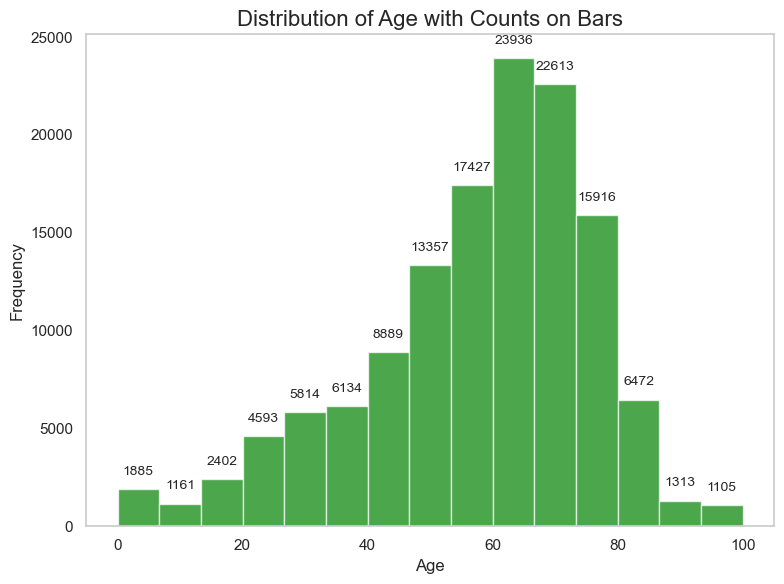

In [170]:
# creating histogram for distribution of age
chart_age_dist = df_DD.hist(column = 'age', bins=15, grid=False, color='green', alpha=0.7, figsize=(8, 6))[0][0]
# Add labels on each bar
for bar in chart_age_dist.patches:
    # Get the height of the bar (frequency count)
    count = int(bar.get_height())
    if count > 0:  # Only annotate non-empty bars
        chart_age_dist.annotate(str(count),
                    xy=(bar.get_x() + bar.get_width() / 2, count),
                    xytext=(0, 8),  # Offset to prevent overlap
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# Add titles and labels
chart_age_dist.set_title('Distribution of Age with Counts on Bars', fontsize=16)
chart_age_dist.set_xlabel('Age', fontsize=12)
chart_age_dist.set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

# Question 58.Plot a 3-D graph using any set of random values chosen by you

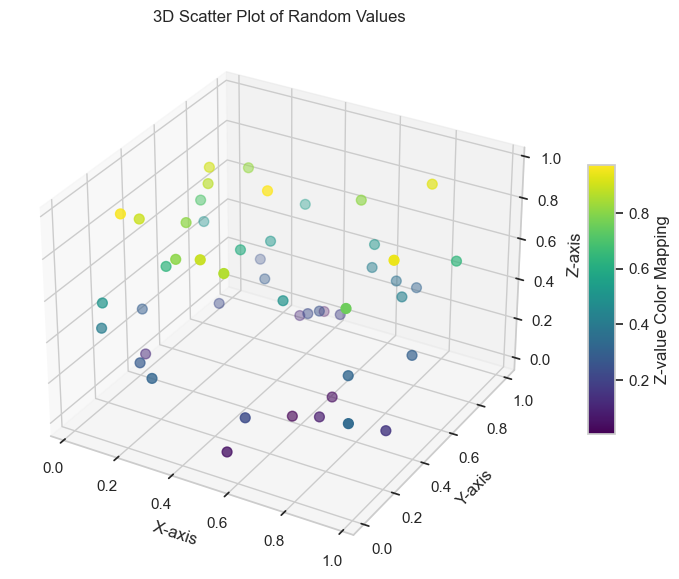

In [171]:
# Generate random data using random seed method
np.random.seed(42)  # For reproducibility
x1 = np.random.rand(50)  
y1 = np.random.rand(50)  
z1 = np.random.rand(50)  

# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax_2= fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax_2.scatter(x1, y1, z1, c=z1, cmap='viridis', marker='o', s=50)

# Add labels and title
ax_2.set_title("3D Scatter Plot of Random Values")
ax_2.set_xlabel("X-axis")
ax_2.set_ylabel("Y-axis")
ax_2.set_zlabel("Z-axis")

# Add a color bar
cbar = plt.colorbar(scatter, ax=ax_2, shrink=0.5, aspect=10)
cbar.set_label('Z-value Color Mapping')

# Show the plot
plt.show()

# Question 59. What % of the dataset is male vs female?

In [172]:
# first get the male and female count,then calculated the percentage
male_female_count = df_DD['gender'].value_counts()
percentage_count = round((male_female_count/male_female_count.sum())*100.0,2)
print(percentage_count)

gender
M    58.83
F    41.17
Name: count, dtype: float64


# Question 60. How many patients of each race are listed under an Unknown cause of death?

In [173]:
#using count method, to find the number of donors for each hospital
donors_unknown_death = df_DD[df_DD['causeofdeath'] == 'Unknown']
donors_per_race = donors_unknown_death.groupby(["race"])["PatientID"].count()
#convert the result into dataframe and name it
donors_per_race.name = "Number_of_Donors_per_race_unknown_deathcause"
donors_per_race = donors_per_race.to_frame()
# Display the result
donors_per_race = donors_per_race.sort_values(by="Number_of_Donors_per_race_unknown_deathcause", ascending=False)
print(donors_per_race)

          Number_of_Donors_per_race_unknown_deathcause
race                                                  
White                                            15994
Black                                             4970
Hispanic                                          4181
Other                                             1635


# 61.Display all records where approached time is more than 2 days after referral time

In [174]:
df_RD_try =df_RD.copy()
# convert time approached into Days
df_RD_try['Days_Diff'] = (df_RD_try['time_approached'] - df_RD_try['time_referred']).dt.days
filtered_records_2days = df_RD_try[df_RD_try['Days_Diff'] > 2]
print('approached time is more than 2 days after referral time:')
print(filtered_records_2days)

approached time is more than 2 days after referral time:
           PatientID  Approached Relatives  Authorized By Family  \
70      OPO1_P278912                     1                     1   
123     OPO1_P420462                     1                     1   
366      OPO1_P37555                     1                     1   
420     OPO1_P698255                     1                     1   
502     OPO1_P476522                     1                     1   
...              ...                   ...                   ...   
132678  OPO6_P564856                     1                     1   
132849   OPO6_P10911                     1                     1   
132930  OPO6_P332293                     1                     1   
132974  OPO6_P313521                     1                     1   
133010  OPO6_P925470                     1                     1   

        Cross_Clamped  transplanted  Tissue_Referral  Eye_Referral  \
70                  1             1                1    

# 62.Display a donut chart of race and explode the wedge with the maximum patients

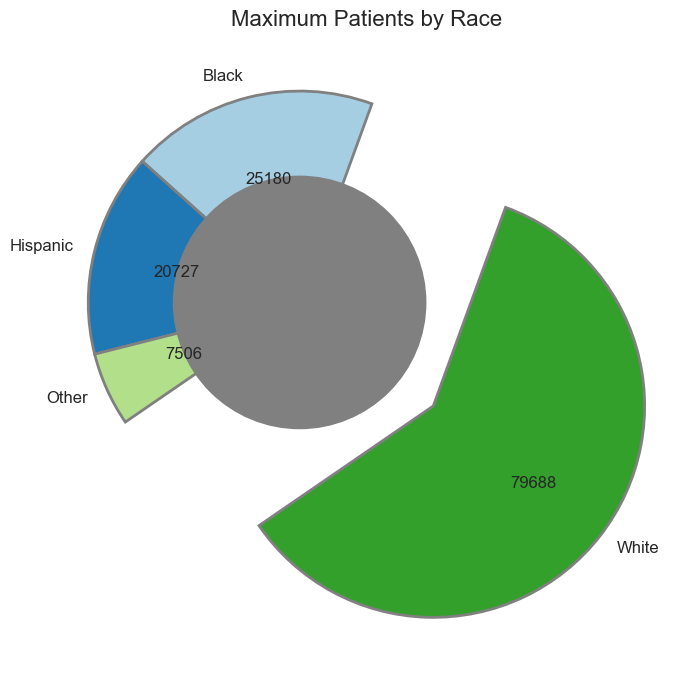

In [175]:
df_DD =pd.read_excel(xls,"DonorDetails")
patients_by_race = df_DD.groupby('race')['PatientID'].count()
race_labels = patients_by_race.index.tolist()
patient_counts = patients_by_race.values.tolist()
max_patients = patient_counts.index(max(patient_counts))
explode = [0] * len(race_labels)
explode[max_patients] = 0.8
colors = plt.cm.Paired.colors[:len(race_labels)]
def count_format(pct, all_vals):
    absolute = int(round(pct / 100.0 * sum(all_vals)))
    return f"{absolute}"

plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    patient_counts,
    labels=race_labels,
    explode=explode,
    autopct=lambda pct: count_format(pct, patient_counts),
    startangle=70,
    colors=colors,
    wedgeprops={"linewidth": 2, "edgecolor": "grey"},
    textprops={"fontsize": 12}
)
center_circle = plt.Circle((0, 0), 0.60, color='grey', linewidth=0)
plt.gca().add_artist(center_circle)
plt.title('Maximum Patients by Race', fontsize=16)
plt.axis("equal")
plt.tight_layout()
plt.show()

# 63.Plot a graph by multiplotting on the same canvas (Take any set of x & y values)

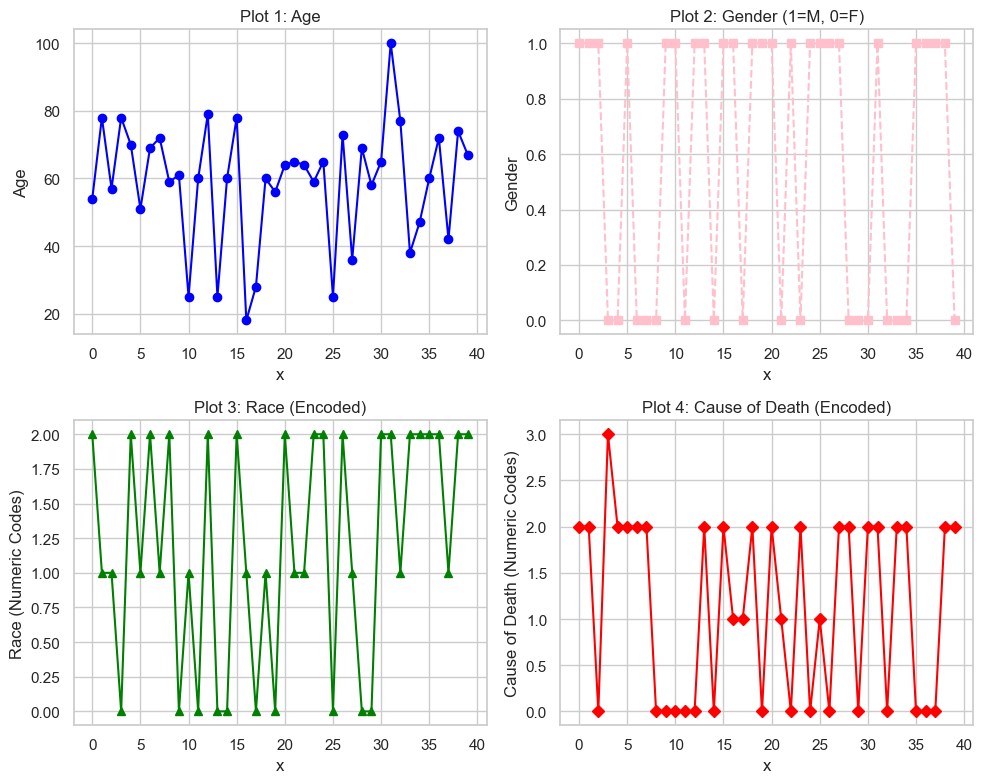

In [176]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_DD_axes = df_DD.copy()
df_DD_axes = df_DD_axes.dropna(subset=["age", "gender", "race", "causeofdeath"])
# X and Y Values
x = df_DD_axes.index[:40]
y_age = df_DD_axes["age"][:40]
y_gender = df_DD_axes["gender"][:40].apply(lambda g: 1 if g == "M" else 0)
y_race = df_DD_axes["race"][:40].astype("category").cat.codes  
y_causeofdeath = df_DD_axes["causeofdeath"][:40].astype("category").cat.codes 

#subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
#First Plot
axes[0, 0].plot(x, y_age, marker="o", color="blue")
axes[0, 0].set_title("Plot 1: Age")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("Age")
#Second Plot
axes[0, 1].plot(x, y_gender, marker="s", color="pink", linestyle="--")
axes[0, 1].set_title("Plot 2: Gender (1=M, 0=F)")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("Gender")
#Third Plot
axes[1, 0].plot(x, y_race, marker="^", color="green")
axes[1, 0].set_title("Plot 3: Race (Encoded)")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("Race (Numeric Codes)")
#Fourth Plot
axes[1, 1].plot(x, y_causeofdeath, marker="D", color="red")
axes[1, 1].set_title("Plot 4: Cause of Death (Encoded)")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("Cause of Death (Numeric Codes)")

plt.tight_layout()
plt.show()


# 64.Replace all null values in 'Procured_year' to 1900

In [177]:
df_RD = pd.read_excel(xls,'ReferralDetails')
df_RD_Procured = df_RD.copy()
df_RD_Procured['Procured_Year'] = df_RD_Procured['Procured_Year'].fillna(1900).astype(int)
print(df_RD_Procured)

           PatientID  Approached Relatives  Authorized By Family  \
0       OPO1_P320866                     0                     0   
1       OPO1_P549364                     0                     0   
2       OPO1_P536997                     1                     0   
3       OPO1_P463285                     0                     0   
4       OPO1_P284978                     0                     0   
...              ...                   ...                   ...   
133096  OPO6_P384794                     0                     0   
133097  OPO6_P902138                     0                     0   
133098    OPO6_P5461                     0                     0   
133099  OPO6_P942291                     0                     0   
133100  OPO6_P210235                     0                     0   

        Cross_Clamped  transplanted  Tissue_Referral  Eye_Referral  \
0                   0             0                1             1   
1                   0             0        

# 65.List any 10 donors that are not there in the outcomes sheet

In [178]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_Out =pd.read_excel(xls,"Outcomes")
not_in_outcome = df_DD [~df_DD["PatientID"].isin(df_Out["PatientID"])]
not_in_outcome_list = not_in_outcome.head(10)

print("10 Donors not in the Outcomes sheet:")
print(not_in_outcome_list)

10 Donors not in the Outcomes sheet:
      PatientID   age gender      race              causeofdeath  \
0  OPO1_P155959  54.0      M     White                   Unknown   
1  OPO1_P297347  78.0      M  Hispanic                   Unknown   
2  OPO1_P399316  57.0      M  Hispanic                    Anoxia   
3  OPO1_P246407  78.0      F     Black  cerebrovascular accident   
4  OPO1_P187209  70.0      F     White                   Unknown   
5  OPO1_P867460  51.0      M  Hispanic                   Unknown   
6  OPO1_P810329  69.0      F     White                   Unknown   
7  OPO1_P652117  72.0      F  Hispanic                   Unknown   
8  OPO1_P833594  59.0      F     White                    Anoxia   
9  OPO1_P193672  61.0      M     Black                    Anoxia   

  mechanism_of_death  brain_death       time_asystole time_brain_death  
0            Unknown            0 2036-01-02 18:26:00              NaT  
1            Unknown            0 2031-12-24 14:06:00              N

# 66.Using stack/unstack functions show the number of donors for each outcome type and cause of death

In [179]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_Out =pd.read_excel(xls,"Outcomes")
df_DD_Copy =df_DD.copy()
df_Out_Copy =df_Out.copy()
outcome_melted = df_Out_Copy.melt(id_vars=["PatientID"], 
                                 var_name="Organ", 
                                 value_name="Outcome_Type")
merged_df = pd.merge(outcome_melted, df_DD_Copy, on="PatientID", how="inner")
grouped = merged_df.groupby(["Outcome_Type", "causeofdeath"])["PatientID"].count()
unstacked = grouped.unstack(fill_value=0) 
print (unstacked)

causeofdeath                                   Aneurysm  Anoxia  CHF  \
Outcome_Type                                                           
Recovered for Research                                0    1807    1   
Recovered for Transplant but not Transplanted         0    1145    0   
Transplanted                                          7   10254    2   

causeofdeath                                   CNS Tumor  Cardiac Arrest  \
Outcome_Type                                                               
Recovered for Research                                22              52   
Recovered for Transplant but not Transplanted          9              34   
Transplanted                                         123             224   

causeofdeath                                   Drowning  Drug Overdose  ESLD  \
Outcome_Type                                                                   
Recovered for Research                                7             27     3   
Recovered for Tran

# 67.plot a time series line graph showing yearly calculated deaths. Color each line by OPO ID

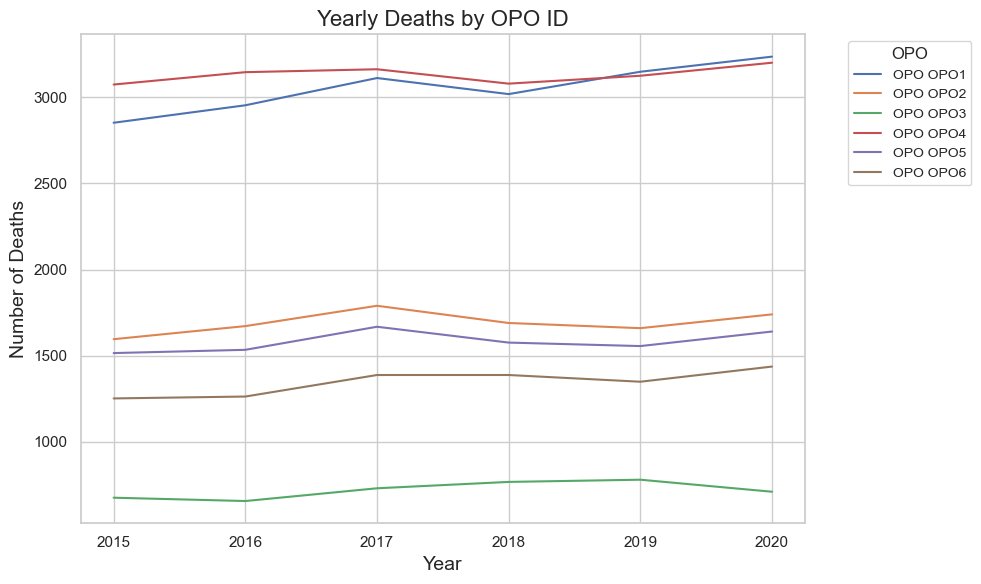

In [180]:
df_Year =pd.read_excel(xls,"Yearly_Outcomes")
df_Year_deaths = df_Year.copy()
yearly_deaths = df_Year_deaths.groupby(['Year', 'OPO'])['mean calc deaths'].sum().reset_index()
pivot_data = yearly_deaths.pivot(index='Year', columns='OPO', values='mean calc deaths')
plt.figure(figsize=(10, 6))
for OPO in pivot_data.columns: 
    plt.plot(pivot_data.index, pivot_data[OPO], label=f'OPO {OPO}')
    plt.title('Yearly Deaths by OPO ID', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Deaths', fontsize=14)
plt.legend(title='OPO', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()

plt.show()

# 68.Create any two 2-dimensional arrays and multiply them. Display the resulting array

In [181]:
array1 = pd.DataFrame([[1, 2], [3, 4]])
array2 = pd.DataFrame([[5, 6], [7, 8]])

array1.dot(array2)

,0,1
0,19,22
1,43,50


# 69.Using a bar chart, which mechnism of death had the lowest count of donors?

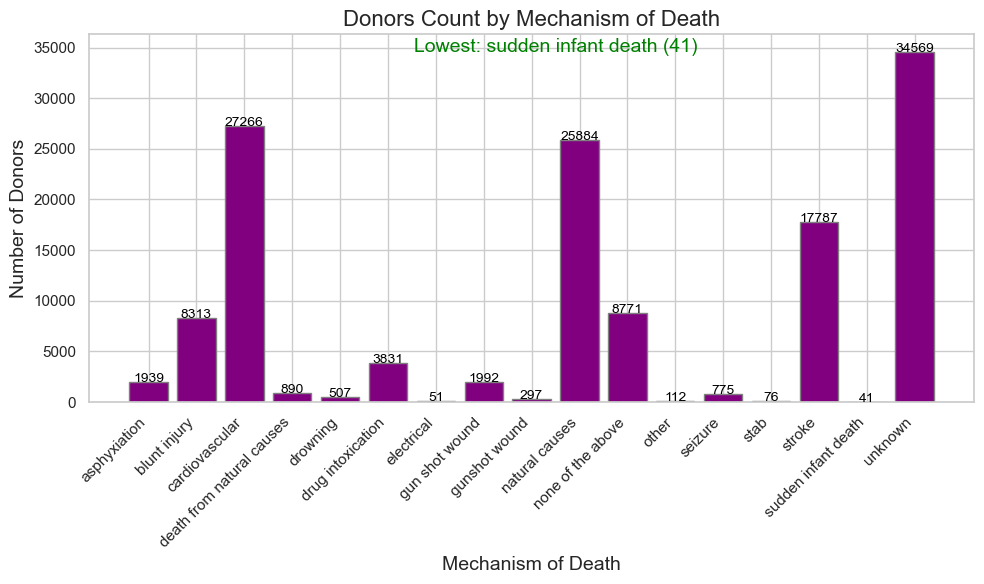

In [182]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_DD_mechism = df_DD.copy()
df_DD_mechism['mechanism_of_death_normalized'] = df_DD_mechism['mechanism_of_death'].str.lower()
mechanism_of_deaths = df_DD_mechism.groupby('mechanism_of_death_normalized')['PatientID'].count()
lowest_mechanism = mechanism_of_deaths.idxmin()
lowest_count = mechanism_of_deaths.min()
plt.figure(figsize=(10, 6))
bars = plt.bar(mechanism_of_deaths.index,mechanism_of_deaths.values, color='Purple', edgecolor='Grey')

        # display the count on each bar
for i, count in enumerate(mechanism_of_deaths):
    plt.text(i, count + 0.1, str(count), ha='center', fontsize=10, color='black')
plt.title("Donors Count by Mechanism of Death", fontsize=16)
plt.xlabel("Mechanism of Death", fontsize=14)
plt.ylabel("Number of Donors", fontsize=14)
plt.xticks(rotation=45, ha="right")

max_height = max(mechanism_of_deaths.values) 
plt.text(len(mechanism_of_deaths) / 2,       
         max_height + 2,                           
         f"Lowest: {lowest_mechanism} ({lowest_count})", 
         color='Green', fontsize=14, ha='center')

plt.tight_layout()
plt.show()


# 70.Using arrays and loops find the number of patients who were referred in the month of July

In [183]:
df_RD =pd.read_excel(xls,"ReferralDetails")
df_RD_referred = df_RD.copy()
count = 0
for patientsreferred in pd.to_datetime(df_RD_referred['time_referred']):
    if (patientsreferred.month == 7):
        count = count + 1

print('Number of patients referred in month of july: {}'.format(count))

Number of patients referred in month of july: 11391


# 71."Which year recorded the highest number of organ procurements from patients who died due to stroke as the mechanism of death? Display this information using a bar chart."

Procured_Year
2015.0    328
2016.0    325
2017.0    327
2018.0    378
2019.0    467
2020.0    406
2021.0    421
2022.0      1
Name: PatientID, dtype: int64


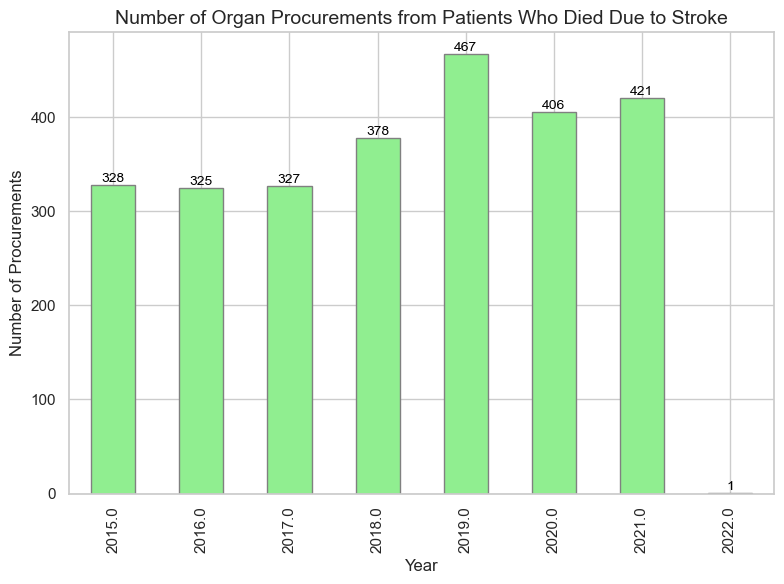

The year with the highest number of organ procurements from stroke patients is 2019.0 with 467 procurements.


In [184]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_Out =pd.read_excel(xls,"Outcomes")
df_RD =pd.read_excel(xls,"ReferralDetails")
df_DD_mechanism =df_DD.copy()
df_Out_procurement =df_Out.copy()
df_RD_referred = df_RD.copy()
stroke_patients = df_DD[df_DD['mechanism_of_death']== 'Stroke']  
merged_df_stroke = pd.merge(stroke_patients, df_RD_referred, on="PatientID", how="inner")
grouped_stroke = merged_df_stroke.groupby(["Procured_Year"])["PatientID"].count()
print(grouped_stroke)

plt.figure(figsize=(8, 6))
stroke_chart= grouped_stroke.plot(kind='bar', color='Lightgreen', edgecolor='gray')
plt.title("Number of Organ Procurements from Patients Who Died Due to Stroke", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Procurements", fontsize=12)

# Adding count values on the bars
for bar in stroke_chart.patches:
   stroke_chart.annotate(
        format(bar.get_height(), '.0f'),  
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  
        ha='center', va='bottom',  
        fontsize=10, color='black' 
    )

plt.tight_layout()
plt.show()
max_year = grouped_stroke.idxmax()
max_count = grouped_stroke.max()

print(f"The year with the highest number of organ procurements from stroke patients is {max_year} with {max_count} procurements.")

# 72.Which organ has the highest chance of being successfully transplanted

In [185]:
# Initialize a dictionary to store counts
df_Outcomes = df_Out.copy()
# Extract transplant outcome columns
organ_columns = ['outcome_heart', 'outcome_liver', 'outcome_kidney_left','outcome_kidney_right','outcome_lung_left','outcome_lung_right',
                'outcome_intestine', 'outcome_pancreas']
# Initialize a dictionary to store counts
transplant_counts = {}
# Loop through each organ column

for organ in organ_columns:
    
    # Count the number of 'Transplanted' outcomes
    transplanted = df_Outcomes[organ].value_counts().get('Transplanted', 0)
    total = df_Outcomes[organ].notna().sum()  # Total records excluding blanks
    transplant_rate = (transplanted / total) * 100  # Calculate percentage
    transplant_counts[organ] = transplant_rate
# Convert dictionary to DataFrame for better readability
transplant_df = pd.DataFrame.from_dict(transplant_counts, orient='index', columns=['Transplant Rate (%)'])
# Sort to find the organ with the highest transplant rate
transplant_df = transplant_df.sort_values(by='Transplant Rate (%)', ascending=False)
# Display the result
print(transplant_df)
max_transplant_organ = transplant_df.idxmax()
max_transplant_count = transplant_df.max()
print(max_transplant_organ)
print(max_transplant_count)

                      Transplant Rate (%)
outcome_liver                   88.762339
outcome_heart                   80.948509
outcome_kidney_left             80.481709
outcome_kidney_right            80.036318
outcome_lung_left               62.987966
outcome_lung_right              61.705831
outcome_pancreas                53.126861
outcome_intestine               23.097826
Transplant Rate (%)    outcome_liver
dtype: object
Transplant Rate (%)    88.762339
dtype: float64


# 73.Create a WordCloud Chart with any column of your choice

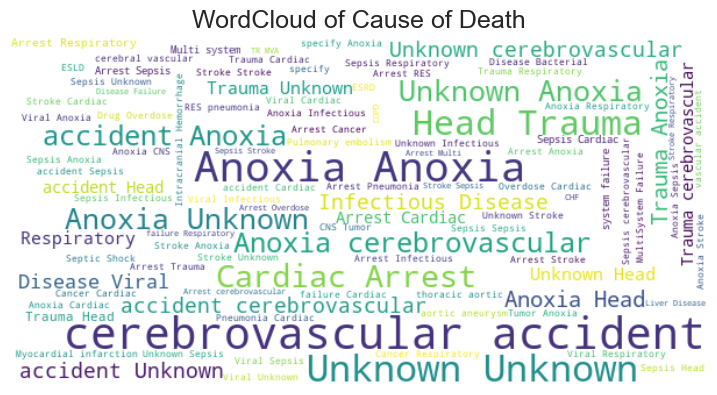

In [186]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_DD_causeofdeath =df_DD.copy()
text_data = " ".join(str(value) for value in df_DD_causeofdeath["causeofdeath"] if pd.notnull(value))
wordcloud = WordCloud(
    width=600, 
    height=300, 
    background_color="white", 
    colormap="viridis",
    max_words=100
).generate(text_data)
plt.figure(figsize=(9, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Cause of Death", fontsize=18)
plt.show()

# 74.Group donors by age into 7 groups using the binning method. Show counts under each bin

In [187]:
# Calling bin_counts_age function created as part of the question 53. (Display a correlation matrix showing count of donors in age group vs cause of death)
# function re using here
bin_counts_age(df_bin_age)

,Number_of_Donors_per_age_group
age_group,
"(0.0, 14.29]",3219
"(14.29, 28.57]",8291
"(28.57, 42.86]",13917
"(42.86, 57.14]",29907
"(57.14, 71.43]",46573
"(71.43, 85.71]",28107
"(85.71, 100.0]",2956


# 75."Can donors who die from cardiac arrest successfully donate their hearts for transplantation? Provide data and evidence from the given dataset to support your answer."

In [188]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_Out =pd.read_excel(xls,"Outcomes")
df_DD_cardiacarrest =df_DD.copy()
df_Out_transplanted =df_Out.copy()

cardiac_arrest_donors = df_DD_cardiacarrest[df_DD_cardiacarrest['causeofdeath'] == 'Cardiac Arrest']
merged_data = pd.merge(cardiac_arrest_donors, df_Out_transplanted, on='PatientID', how='inner')
heart_transplants = merged_data['outcome_heart'].value_counts()
print('Heart Transplant Outcomes for Donors with Cardiac Arrest:')
print(heart_transplants)
if "Transplanted" in heart_transplants:
    total_donors = len(cardiac_arrest_donors)
    successful_transplants = heart_transplants.get("Transplanted", 0)
    percentage_success = (successful_transplants / total_donors) * 100
    print(f"\nOut of {total_donors} donors who died of cardiac arrest, "
          f"{successful_transplants} successfully donated their hearts for transplantation ({percentage_success:.2f}%).")
else:
    print("\nNo donors who died of cardiac arrest successfully donated their hearts for transplantation.")

Heart Transplant Outcomes for Donors with Cardiac Arrest:
outcome_heart
Transplanted                                     14
Recovered for Research                            6
Recovered for Transplant but not Transplanted     1
Name: count, dtype: int64

Out of 8041 donors who died of cardiac arrest, 14 successfully donated their hearts for transplantation (0.17%).


# 76.Which organ has the highest frequency of procurement.

In [189]:
# Initialize a dictionary to store counts
df_Outcomes = df_Out.copy()
# Extract transplant outcome columns
organ_columns = ['outcome_heart', 'outcome_liver', 'outcome_kidney_left','outcome_kidney_right','outcome_lung_left','outcome_lung_right',
                'outcome_intestine', 'outcome_pancreas']
# Initialize a dictionary to store procurement counts
procurement_counts = {}
# Loop through each organ column

for organ in organ_columns:

    
    # Count non-null values (indicating procurement occurred)
    procurement_count = df_Outcomes[organ].notna().sum()
    procurement_counts[organ] = procurement_count
# Convert dictionary to DataFrame for better readability
procurement_df = pd.DataFrame.from_dict(procurement_counts, orient='index', columns=['Procurement Count'])
# Sort to find the organ with the highest procurement frequency
procurement_df = procurement_df.sort_values(by='Procurement Count', ascending=False)
max_procurement_count = procurement_df.idxmax()
max_procurement_counts = procurement_df.max()

print(f"Which organ has the highest frequency of procurement is: {max_procurement_count} with {max_procurement_counts} procurements.")
print(procurement_df)


Which organ has the highest frequency of procurement is: Procurement Count    outcome_kidney_right
dtype: object with Procurement Count    8811
dtype: int64 procurements.
                      Procurement Count
outcome_kidney_right               8811
outcome_kidney_left                8802
outcome_liver                      7902
outcome_heart                      3690
outcome_lung_right                 3447
outcome_lung_left                  3407
outcome_pancreas                   1679
outcome_intestine                   368


# 77.Using loops, create a multiplication table for the number 8

In [190]:
for i in range(1, 11):
    result = 8 * i
    print("8 x", i, "=", result)

8 x 1 = 8
8 x 2 = 16
8 x 3 = 24
8 x 4 = 32
8 x 5 = 40
8 x 6 = 48
8 x 7 = 56
8 x 8 = 64
8 x 9 = 72
8 x 10 = 80


# 78.Display random data by splitting it into 4 quartiles and labeling the quartiles.

           PatientID   age gender      race             causeofdeath  \
116336  OPO5_P936572  53.0      M     Black  Intracranial Hemorrhage   
103255  OPO1_P297652  79.0      F     White                    Other   
58871   OPO4_P849781  69.0      M     Other                   Anoxia   
115403  OPO3_P558992  53.0      M     White      Respiratory - Other   
27107   OPO1_P666141  65.0      F     Black                   Anoxia   
121561  OPO6_P879588  75.0      M     White      Respiratory - Other   
130071  OPO6_P750064  54.0      F     White                   Sepsis   
15363    OPO1_P11586  61.0      M     White              Head Trauma   
10170   OPO1_P256775  61.0      M  Hispanic                  Unknown   
74456   OPO4_P721475  57.0      M     Black                   Anoxia   

       mechanism_of_death  brain_death       time_asystole time_brain_death  \
116336             Stroke            0 2033-12-12 21:27:00              NaT   
103255            Unknown            0 2033-05-01

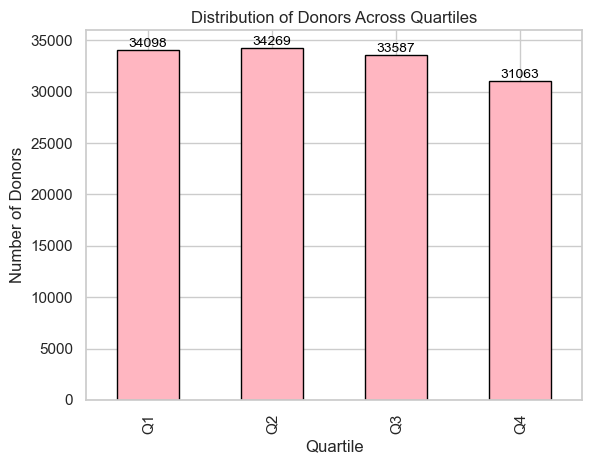

In [191]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_DD_quartiles =df_DD.copy()

numeric_column = 'age'
df_DD_quartiles  = df_DD_quartiles.dropna(subset=[numeric_column])
df_DD_quartiles ['Quartile'] = pd.qcut(
    df_DD_quartiles[numeric_column], 
    q=4, 
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)
random_data = df_DD_quartiles.sample(10)
print(random_data)

chart_random= df_DD_quartiles['Quartile'].value_counts().sort_index().plot(
    kind='bar', 
    color='lightpink', 
    edgecolor='black', 
    title='Distribution of Donors Across Quartiles'
)
# Adding count values on the bars
for bar in chart_random.patches:
   chart_random.annotate(
        format(bar.get_height(), '.0f'),  
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  
        ha='center', va='bottom',  
        fontsize=10, color='black' 
    )
plt.xlabel('Quartile')
plt.ylabel('Number of Donors')
plt.show()

# 79.Display all details of the oldest female patient


In [192]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_RD_Fpatients = df_DD.copy()
female_patients= df_RD_Fpatients[df_RD_Fpatients['gender'] == 'F']
max_age = female_patients['age'].max()
oldest_female_patients= female_patients[female_patients['age'] == max_age]

print ('All details of the oldest female patients:')
print (oldest_female_patients)


All details of the oldest female patients:
           PatientID    age gender      race              causeofdeath  \
290      OPO1_P26983  100.0      F     Black                   Unknown   
296     OPO1_P453980  100.0      F  Hispanic                   Unknown   
1329     OPO1_P54734  100.0      F  Hispanic                   Unknown   
1334    OPO1_P401445  100.0      F  Hispanic                   Unknown   
1474    OPO1_P679369  100.0      F  Hispanic  cerebrovascular accident   
...              ...    ...    ...       ...                       ...   
131853  OPO6_P502575  100.0      F     White       Respiratory - Other   
132309  OPO6_P987294  100.0      F     Other                     Other   
132441  OPO6_P548254  100.0      F  Hispanic       Respiratory - Other   
132594  OPO6_P155922  100.0      F     White                     Other   
132857  OPO6_P421530  100.0      F     White            Cardiac Arrest   

       mechanism_of_death  brain_death       time_asystole time_brai

# 80.Create a point Plot on Age against Cardiac arrest.

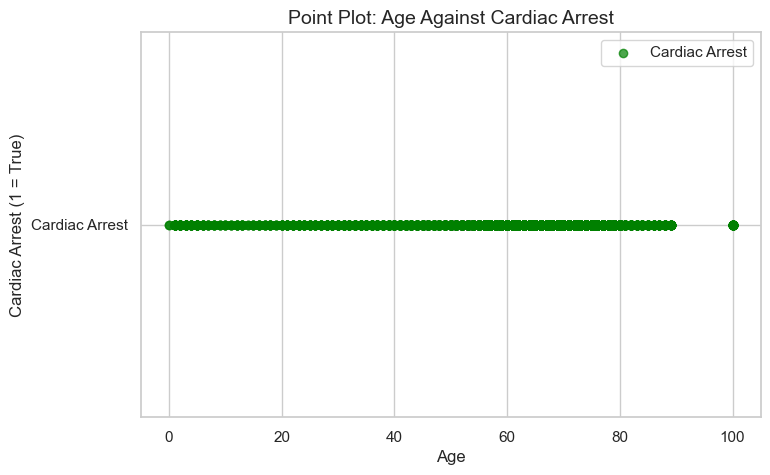

In [193]:
df_DD =pd.read_excel(xls,"DonorDetails")
df_DD_Cardiacarrest =df_DD.copy()
 
if "age" in df_DD_Cardiacarrest.columns and 'causeofdeath' in df_DD_Cardiacarrest.columns:
 
    cardiac_arrest_data = df_DD_Cardiacarrest[df_DD_Cardiacarrest['causeofdeath'].str.contains('Cardiac Arrest', case=False, na=False)]
    
    plt.figure(figsize=(8, 5))
    plt.scatter(cardiac_arrest_data['age'], [1] * len(cardiac_arrest_data), c="Green", label='Cardiac Arrest', alpha=0.7)
    
    plt.title('Point Plot: Age Against Cardiac Arrest', fontsize=14)
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Cardiac Arrest (1 = True)', fontsize=12)
    plt.yticks([1], ['Cardiac Arrest'])
    
    plt.legend()
    plt.show()
else:

    print(f"Required columns: {age}, {causeofdeath} cases")